## Improved K-Shadow Membership-Inference Prototype

### Purpose
Quantify whether a record-linkage model's predictions reveal if a record pair was used
during training, using the same Siamese-encoder-plus-classification-head architecture,
data pools and validation checks established in `SNN Final end to end (1).ipynb` and
`K_Shadow_Prototype.ipynb`.

### What changed from the earlier prototype
- Reuses the already-completed shadow/target experiment saved in
  `k_runs/main_20260920_230533/` instead of retraining every model from scratch on
  each run.
- Reuses the embedding validation and target/shadow pair-separation checks from the
  initial notebooks before any training happens.
- Only trains the additional shadow models needed when `K_MODELS` exceeds what is
  already cached; existing models are loaded, not repeated.
- Persists any newly trained models, histories and attack artifacts to a timestamped
  `k_runs/` directory, following the same layout as the initial experiment, so later
  runs (including this one) can reuse them too.
- Saves the attack classifier, ROC curve and metrics, and prints the reference
  numbers from the completed initial experiment for comparison.

### Label definitions
- **Linkage label:** whether two records match (the record-linkage task).
- **Membership label:** whether a record pair was used to train the specific model
  being queried (the membership-inference task).

### Scope
This notebook measures membership-inference risk only. Record-linkage accuracy for
the deployed target model is reported separately in
`SNN Final end to end (1).ipynb`.


In [1]:
import gc
import json
from pathlib import Path
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print("Imports ready.")
print("TensorFlow:", tf.__version__)

Imports ready.
TensorFlow: 2.13.1


In [2]:
# ==============================================================================
# 1. SETUP & CONFIG
# ==============================================================================
# Settings match the completed experiment in K_Shadow_Prototype.ipynb so cached
# artifacts can be reused directly instead of retraining.

SEED = 2026
SIAMESE_EPOCHS, HEAD_EPOCHS, BATCH_SIZE = 30, 20, 256
TRAIN_RATIO, QUERY_RATIO = 0.70, 0.30
K_MODELS = 25  # Set any K desired (e.g. 5, 10, 15, ...)

DATA_DIR = Path("Embeddings")
DATASET_DIR = Path("Datasets")
RUN_ROOT = Path("k_runs")

# Default: reuse the completed target + shadow computations instead of retraining.
# Set TRAIN_NEW_RUN = True to force a fresh target and fresh shadow models.
TRAIN_NEW_RUN = False
CACHED_RUN = RUN_ROOT / "main_20260920_230533"

if not TRAIN_NEW_RUN:
    assert CACHED_RUN.is_dir(), (
        f"Cached run not found: {CACHED_RUN.resolve()}. "
        "Set TRAIN_NEW_RUN = True to train from scratch."
    )
    print("Mode: reuse cached target/shadow computations from", CACHED_RUN.resolve())
else:
    print("Mode: train a new target and", K_MODELS, "new shadow models.")

Mode: reuse cached target/shadow computations from /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/k_runs/main_20260920_230533


In [3]:
# ==============================================================================
# 2. DATA VALIDATION
# Reused from "SNN Final end to end (1).ipynb" and "K_Shadow_Prototype.ipynb" so
# this notebook checks the same invariants before any model is trained.
# ==============================================================================
def validate_embedding_split(x1, x2, y, name):
    """Repeat the structural checks performed in the initial notebooks."""
    assert x1.ndim == x2.ndim == 2, f"{name}: embeddings must be matrices"
    assert y.ndim == 1, f"{name}: labels must be one-dimensional"
    assert x1.shape == x2.shape == (len(y), 768), f"{name}: shape mismatch"
    assert np.isfinite(x1).all() and np.isfinite(x2).all(), f"{name}: NaN/Inf"
    assert np.isin(y, [0, 1]).all(), f"{name}: invalid labels"


def pair_keys(frame):
    """Represent each record pair consistently, including reversed pairs."""
    return {
        tuple(sorted((a, b)))
        for a, b in frame[["uid1", "uid2"]].itertuples(index=False, name=None)
    }


target_csv = pd.read_csv(DATASET_DIR / "target_train.csv", dtype={"uid1": str, "uid2": str})
shadow_csv = pd.read_csv(DATASET_DIR / "shadow_train.csv", dtype={"uid1": str, "uid2": str})

assert not target_csv[["uid1", "uid2", "label"]].isna().any().any(), "Target train: missing values"
assert not shadow_csv[["uid1", "uid2", "label"]].isna().any().any(), "Shadow train: missing values"

shared_pairs = pair_keys(target_csv) & pair_keys(shadow_csv)
assert not shared_pairs, "Target and shadow pools share record pairs; review before training."
print("Pair-separation check passed: target/shadow pools do not share record pairs.")

# Load precomputed .npy embeddings directly (no re-encoding, no duplicated tables).
target_x1 = np.load(DATA_DIR / "x1_target_train.npy", allow_pickle=False)
target_x2 = np.load(DATA_DIR / "x2_target_train.npy", allow_pickle=False)
target_y = np.load(DATA_DIR / "y_target_train.npy", allow_pickle=False)

shadow_x1 = np.load(DATA_DIR / "x1_shadow_train.npy", allow_pickle=False)
shadow_x2 = np.load(DATA_DIR / "x2_shadow_train.npy", allow_pickle=False)
shadow_y = np.load(DATA_DIR / "y_shadow_train.npy", allow_pickle=False)

validate_embedding_split(target_x1, target_x2, target_y, "Target train")
validate_embedding_split(shadow_x1, shadow_x2, shadow_y, "Shadow train")

assert len(target_csv) == len(target_y), "Target train: CSV/embedding row-count mismatch"
assert np.array_equal(target_csv["label"].to_numpy(), target_y), "Target train: label mismatch"
assert len(shadow_csv) == len(shadow_y), "Shadow train: CSV/embedding row-count mismatch"
assert np.array_equal(shadow_csv["label"].to_numpy(), shadow_y), "Shadow train: label mismatch"

print(f"Target train: {target_x1.shape[0]:,} pairs validated.")
print(f"Shadow train: {shadow_x1.shape[0]:,} pairs validated.")

Pair-separation check passed: target/shadow pools do not share record pairs.
Target train: 32,000 pairs validated.
Shadow train: 32,000 pairs validated.


In [4]:
# ==============================================================================
# 3. REUSABLE MODEL BUILDER
# Architecture and loss are identical to build_siamese_autoencoder /
# build_shadow_model in the initial notebooks, so target and shadow models remain
# directly comparable to the completed experiment.
# ==============================================================================
def build_siamese_network(dim=768):
    """Builds the Siamese autoencoder and the linkage classification head."""
    L = tf.keras.layers

    # Shared Encoder
    enc_in = L.Input(shape=(dim,))
    h = L.LeakyReLU(alpha=0.01)(L.Dense(50, activity_regularizer=tf.keras.regularizers.l1(0.01))(enc_in))
    encoder = tf.keras.Model(enc_in, L.Dense(dim, activation="relu")(h), name="encoder")

    # Decoder & Siamese Pair
    dec_in = L.Input(shape=(dim,))
    decoder = tf.keras.Model(dec_in, L.Dense(dim, activation="sigmoid")(dec_in), name="decoder")

    l_in, r_in = L.Input(shape=(dim,)), L.Input(shape=(dim,))
    siamese = tf.keras.Model([l_in, r_in], L.Concatenate()([decoder(encoder(l_in)), decoder(encoder(r_in))]))

    def contrastive_loss(y_true, y_pred):
        l, r = y_pred[:, :dim], y_pred[:, dim:]
        sq_dist = tf.reduce_sum(tf.square(l - r), axis=1)
        dist = tf.sqrt(tf.maximum(sq_dist, tf.keras.backend.epsilon()))
        y = tf.reshape(tf.cast(y_true, tf.float32), [-1])
        return tf.reduce_mean(
            tf.reduce_mean(tf.square(l - r), axis=1)
            + y * sq_dist + (1.0 - y) * tf.square(tf.maximum(2.5 - dist, 0.0))
        )

    siamese.compile(optimizer="adam", loss=contrastive_loss)

    # Linkage Classification Head
    head = tf.keras.Sequential([
        L.Input(shape=(dim,)),
        L.Dense(64, activation="relu"),
        L.Dense(32, activation="relu"),
        L.Dense(1, activation="sigmoid"),
    ])
    head.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return siamese, encoder, head


print("Model builder ready.")

Model builder ready.


In [5]:
# ==============================================================================
# 4. RUNNER: TRAIN MODEL, EXTRACT LINKAGE SCORES, OPTIONALLY PERSIST ARTIFACTS
# ==============================================================================
def train_and_query_model(x1, x2, y, seed, run_name="model", save_dir=None):
    """Trains Siamese + head and collects balanced membership evaluation queries.

    When save_dir is given, persists the encoder, head, split indices and
    training histories so this model can be reused by future runs, matching the
    layout already used under k_runs/ by the initial K_Shadow_Prototype experiment.
    """
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    train_idx, hold_idx = train_test_split(
        np.arange(len(y)), test_size=1.0 - TRAIN_RATIO, stratify=y, random_state=seed
    )

    siamese, encoder, head = build_siamese_network(x1.shape[1])

    # Train Siamese encoder
    siamese_history = siamese.fit(
        [x1[train_idx], x2[train_idx]], y[train_idx],
        epochs=SIAMESE_EPOCHS, batch_size=BATCH_SIZE, verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )

    # Feature extraction helper: |Encoder(x1) - Encoder(x2)|
    def extract_features(indices):
        e1 = encoder.predict(x1[indices], batch_size=BATCH_SIZE, verbose=0)
        e2 = encoder.predict(x2[indices], batch_size=BATCH_SIZE, verbose=0)
        return np.abs(e1 - e2)

    # Train linkage head on members
    head_history = head.fit(
        extract_features(train_idx), y[train_idx],
        epochs=HEAD_EPOCHS, batch_size=BATCH_SIZE, verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )

    # Sample balanced query set: members (1) and non-members (0)
    rng = np.random.default_rng(seed)
    n_q = min(int(QUERY_RATIO * len(train_idx)), len(hold_idx))
    member_idx = rng.choice(train_idx, n_q, replace=False)
    non_member_idx = rng.choice(hold_idx, n_q, replace=False)

    query_idx = np.concatenate([member_idx, non_member_idx])
    p_match = head.predict(extract_features(query_idx), batch_size=BATCH_SIZE, verbose=0).ravel()

    df = pd.DataFrame({
        "embedding_row": query_idx,
        "p_match": p_match,
        "linkage_label": y[query_idx],
        "membership": np.r_[np.ones(n_q, dtype=int), np.zeros(n_q, dtype=int)],
    })

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        encoder.save(str(save_dir / "encoder.keras"))
        head.save(str(save_dir / "linkage_head.keras"))
        df.to_csv(save_dir / "membership_outputs.csv", index=False)
        pd.DataFrame(siamese_history.history).to_csv(save_dir / "siamese_history.csv", index=False)
        pd.DataFrame(head_history.history).to_csv(save_dir / "head_history.csv", index=False)
        np.savez(save_dir / "split_indices.npz", train_idx=train_idx, hold_idx=hold_idx)
        (save_dir / "complete.json").write_text(
            json.dumps({"run_name": run_name, "seed": seed}, indent=2), encoding="utf-8"
        )

    del siamese, encoder, head
    gc.collect()
    return df


print("Runner ready.")

Runner ready.


In [6]:
# ==============================================================================
# 5. RUN TARGET + K SHADOW MODELS
# Reuses cached computations by default; only trains whatever is missing from
# the cache (e.g. shadow models beyond the 10 already completed).
# ==============================================================================
def load_cached_outputs(directory, model_name):
    path = directory / model_name / "membership_outputs.csv"
    return pd.read_csv(path) if path.is_file() else None


run_dir = CACHED_RUN if not TRAIN_NEW_RUN else RUN_ROOT / ("new_k_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f"))

# --- Target model ---
target_queries = None if TRAIN_NEW_RUN else load_cached_outputs(run_dir, "target")
if target_queries is None:
    print("Training target model...")
    target_queries = train_and_query_model(
        target_x1, target_x2, target_y, seed=SEED, run_name="target",
        save_dir=run_dir / "target",
    )
else:
    print("Reusing cached target outputs:", len(target_queries), "queries.")

# --- K shadow models (only trains any that are missing from the cache) ---
shadow_dfs = []
for k in range(1, K_MODELS + 1):
    cached = None if TRAIN_NEW_RUN else load_cached_outputs(run_dir, f"shadow_{k}")
    if cached is not None:
        print(f"Reusing cached shadow model {k}/{K_MODELS}.")
        s_df = cached
    else:
        print(f"Training shadow model {k}/{K_MODELS}...")
        s_df = train_and_query_model(
            shadow_x1, shadow_x2, shadow_y, seed=SEED + k, run_name=f"shadow_{k}",
            save_dir=run_dir / f"shadow_{k}",
        )
    s_df = s_df.copy()
    s_df["shadow_id"] = k
    shadow_dfs.append(s_df)

shadow_queries = pd.concat(shadow_dfs, ignore_index=True)
print(f"\nReady: {len(target_queries)} target queries, {len(shadow_queries)} shadow queries across {K_MODELS} shadow models.")
print("Run directory:", run_dir.resolve())

Reusing cached target outputs: 13440 queries.
Reusing cached shadow model 1/25.
Reusing cached shadow model 2/25.
Reusing cached shadow model 3/25.
Reusing cached shadow model 4/25.
Reusing cached shadow model 5/25.
Reusing cached shadow model 6/25.
Reusing cached shadow model 7/25.
Reusing cached shadow model 8/25.
Reusing cached shadow model 9/25.
Reusing cached shadow model 10/25.
Reusing cached shadow model 11/25.
Reusing cached shadow model 12/25.
Reusing cached shadow model 13/25.
Reusing cached shadow model 14/25.
Reusing cached shadow model 15/25.
Reusing cached shadow model 16/25.
Reusing cached shadow model 17/25.
Reusing cached shadow model 18/25.
Reusing cached shadow model 19/25.
Reusing cached shadow model 20/25.
Reusing cached shadow model 21/25.
Reusing cached shadow model 22/25.
Reusing cached shadow model 23/25.
Reusing cached shadow model 24/25.
Reusing cached shadow model 25/25.

Ready: 13440 target queries, 335970 shadow queries across 25 shadow models.
Run directo

Model selection on shadow data (5-fold CV ROC AUC):
  logistic_regression : 0.5329 (+/- 0.0071)
  random_forest       : 0.5362 (+/- 0.0095)
  gradient_boosting   : 0.5361 (+/- 0.0090)

Selected: random_forest

MEMBERSHIP INFERENCE EVALUATION (K = 25, model = random_forest)
Accuracy : 0.5315
Precision: 0.5177
Recall   : 0.9202
F1 Score : 0.6627
ROC AUC  : 0.5441


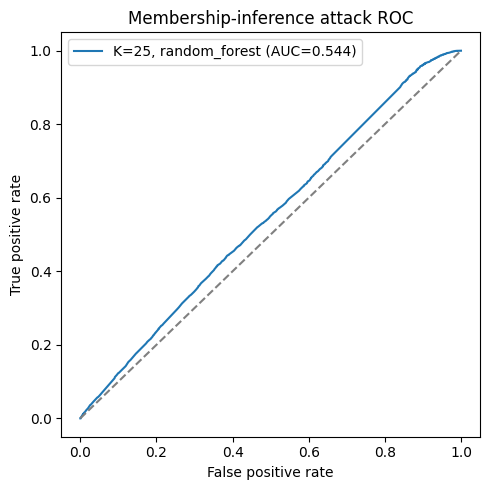


Saved attack model, metrics and ROC curve to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/k_runs/main_20260920_230533/attack_evaluation


In [7]:
# ==============================================================================
# 6. CONDENSED MEMBERSHIP INFERENCE ATTACK (v2: richer features + nonlinear classifier)
# ==============================================================================
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score


def build_attack_features(df):
    """Attack features, redesigned from the diagnostic findings:
    - p_match: raw linkage probability.
    - entropy: binary entropy of p_match (captures curvature near 0.5 that
      a linear model on p_match alone would miss).
    - log_loss: log1p of the per-example cross-entropy loss against the true
      linkage_label. log1p compresses the heavy right skew in raw loss
      (most pairs are near-zero loss; only a thin tail differs by
      membership), which is what distorted the v1 logistic-regression
      threshold.
    - sq_error: (p_match - linkage_label)^2, a Brier-score-style companion
      to log_loss with different tail sensitivity, giving the classifier
      two complementary "how wrong was the model" signals.
    "confidence" from v1 is dropped: it is a monotonic reparameterization
    of p_match and entropy, so it added collinearity without new signal.
    """
    p = np.clip(df["p_match"].to_numpy(), 1e-7, 1.0 - 1e-7)
    entropy = -p * np.log(p) - (1.0 - p) * np.log(1.0 - p)

    y = df["linkage_label"].to_numpy()
    raw_loss = -(y * np.log(p) + (1.0 - y) * np.log(1.0 - p))
    log_loss_feat = np.log1p(raw_loss)
    sq_error = (p - y) ** 2

    return np.column_stack([p, entropy, log_loss_feat, sq_error])


X_train_mia = build_attack_features(shadow_queries)
y_train_mia = shadow_queries["membership"].to_numpy()

X_eval_mia = build_attack_features(target_queries)
y_eval_mia = target_queries["membership"].to_numpy()

# Compare a few classifier families on the shadow data via cross-validation
# (model selection happens entirely on shadow data - the target set is only
# touched once, at the end, by the chosen model).
candidates = {
    "logistic_regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=1000, random_state=SEED)
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300, max_depth=4, min_samples_leaf=50, random_state=SEED
    ),
    "gradient_boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=SEED
    ),
}

print("Model selection on shadow data (5-fold CV ROC AUC):")
cv_scores = {}
for name, model in candidates.items():
    scores = cross_val_score(model, X_train_mia, y_train_mia, cv=5, scoring="roc_auc")
    cv_scores[name] = scores.mean()
    print(f"  {name:20s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

best_name = max(cv_scores, key=cv_scores.get)
attack_model = candidates[best_name]
print(f"\nSelected: {best_name}")

attack_model.fit(X_train_mia, y_train_mia)
scores = attack_model.predict_proba(X_eval_mia)[:, 1]
preds = (scores >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_eval_mia, preds).ravel()
metrics = {
    "K": K_MODELS,
    "attack_model": best_name,
    "attack_training_examples": int(len(y_train_mia)),
    "target_evaluation_examples": int(len(y_eval_mia)),
    "accuracy": float(accuracy_score(y_eval_mia, preds)),
    "precision": float(precision_score(y_eval_mia, preds, zero_division=0)),
    "recall": float(recall_score(y_eval_mia, preds, zero_division=0)),
    "f1": float(f1_score(y_eval_mia, preds, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_eval_mia, scores)),
    "true_negative": int(tn), "false_positive": int(fp),
    "false_negative": int(fn), "true_positive": int(tp),
}

print("\n" + "=" * 50)
print(f"MEMBERSHIP INFERENCE EVALUATION (K = {K_MODELS}, model = {best_name})")
print("=" * 50)
accuracy = metrics["accuracy"]
precision = metrics["precision"]
recall = metrics["recall"]
f1 = metrics["f1"]
roc_auc = metrics["roc_auc"]
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

evaluation_dir = run_dir / "attack_evaluation"
evaluation_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(attack_model, evaluation_dir / f"attack_K{K_MODELS}_{best_name}.joblib")
with (evaluation_dir / f"metrics_K{K_MODELS}_{best_name}.json").open("w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

fpr, tpr, _ = roc_curve(y_eval_mia, scores)
pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv(evaluation_dir / f"roc_K{K_MODELS}_{best_name}.csv", index=False)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"K={K_MODELS}, {best_name} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Membership-inference attack ROC")
plt.legend()
plt.tight_layout()
plt.savefig(evaluation_dir / f"roc_K{K_MODELS}_{best_name}.png", dpi=150)
plt.show()

print("\nSaved attack model, metrics and ROC curve to:", evaluation_dir.resolve())


In [8]:
# ==============================================================================
# 7. OVERFITTING DIAGNOSTIC (train vs held-out gap for the target model)
# ==============================================================================
# Membership-inference success is bounded by how much the target model
# overfits: if train and held-out performance are close, no attack -
# regardless of K or classifier choice - will beat chance by much.
# Reuses target_queries directly (already computed by the target model)
# instead of reloading the saved .keras files, avoiding a Keras
# save/load format mismatch between training and reload environments.
from sklearn.metrics import log_loss

def evaluate_group(df, membership_value, label):
    subset = df[df["membership"] == membership_value]
    p = np.clip(subset["p_match"].to_numpy(), 1e-7, 1.0 - 1e-7)
    y_true = subset["linkage_label"].to_numpy()

    accuracy = float(((p >= 0.5).astype(int) == y_true).mean())
    loss = float(log_loss(y_true, p))

    print(f"{label:10s}: n={len(subset):6d}  accuracy={accuracy:.4f}  loss={loss:.4f}")
    return accuracy, loss


print("\n" + "=" * 50)
print("TARGET MODEL: TRAIN vs HELD-OUT GAP")
print("=" * 50)
train_acc, train_loss = evaluate_group(target_queries, 1, "Train")
hold_acc, hold_loss = evaluate_group(target_queries, 0, "Held-out")

acc_gap = train_acc - hold_acc
loss_gap = hold_loss - train_loss

print(f"\nAccuracy gap (train - held-out): {acc_gap:.4f}")
print(f"Loss gap (held-out - train)   : {loss_gap:.4f}")

if acc_gap < 0.03 and loss_gap < 0.05:
    print(
        "\nVerdict: minimal overfitting. The ~0.54 attack ROC AUC ceiling seen "
        "across K=5..25 is a structural limit of this target model, not a "
        "weakness in the shadow-model attack setup."
    )
else:
    print(
        "\nVerdict: a meaningful train/held-out gap exists. There is more "
        "membership signal available than the current attack features "
        "(p_match, confidence, entropy) are capturing - consider adding a "
        "per-example loss feature to the attack classifier."
    )



TARGET MODEL: TRAIN vs HELD-OUT GAP
Train     : n=  6720  accuracy=0.9787  loss=0.0624
Held-out  : n=  6720  accuracy=0.9314  loss=0.2121

Accuracy gap (train - held-out): 0.0473
Loss gap (held-out - train)   : 0.1497

Verdict: a meaningful train/held-out gap exists. There is more membership signal available than the current attack features (p_match, confidence, entropy) are capturing - consider adding a per-example loss feature to the attack classifier.



=== Overfitting level: baseline (l1=0.01, epochs=30) ===


2026-09-27 12:58:45.586340: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-09-27 12:58:45.586778: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-09-27 12:58:45.587184: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-09-27 12:58:45.587886: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-27 12:58:45.588627: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-09-27 12:58:46.538869: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 12:59:10.807448: I te

Target train_acc=0.9248  hold_acc=0.8958  gen_gap=0.0290  attack_auc=0.5190

=== Overfitting level: weak_reg (l1=0.001, epochs=30) ===


2026-09-27 13:02:33.760406: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:02:58.420229: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:02:59.154084: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:03:07.581268: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:03:08.512203: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:03:35.108966: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:03:35.836453: I tensorflow/core/grappler/optimizers/cust

Target train_acc=0.9211  hold_acc=0.9012  gen_gap=0.0199  attack_auc=0.5205

=== Overfitting level: no_reg (l1=0.0, epochs=30) ===


...

Target train_acc=0.9583  hold_acc=0.9284  gen_gap=0.0299  attack_auc=0.5222

=== Overfitting level: no_reg_long (l1=0.0, epochs=80) ===


2026-09-27 13:10:06.951882: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:11:09.205696: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:11:09.874272: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:11:17.993631: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:11:18.933406: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:12:26.286139: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:12:27.078252: I tensorflow/core/grappler/optimizers/cust

Target train_acc=0.9455  hold_acc=0.9103  gen_gap=0.0353  attack_auc=0.5308

=== Overfitting level: no_reg_longer (l1=0.0, epochs=150) ===


2026-09-27 13:18:29.893825: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:20:39.415163: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:20:40.110671: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:20:48.691254: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:20:49.765774: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:22:57.333939: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 13:22:58.073819: I tensorflow/core/grappler/optimizers/cust

Target train_acc=0.9239  hold_acc=0.8890  gen_gap=0.0350  attack_auc=0.5193

        level  l1_strength  siamese_epochs  train_acc  hold_acc  gen_gap  attack_auc
     baseline        0.010              30   0.924840  0.895818 0.029022    0.518951
     weak_reg        0.001              30   0.921119  0.901176 0.019943    0.520476
       no_reg        0.000              30   0.958327  0.928412 0.029915    0.522198
  no_reg_long        0.000              80   0.945528  0.910255 0.035273    0.530762
no_reg_longer        0.000             150   0.923947  0.888972 0.034975    0.519314


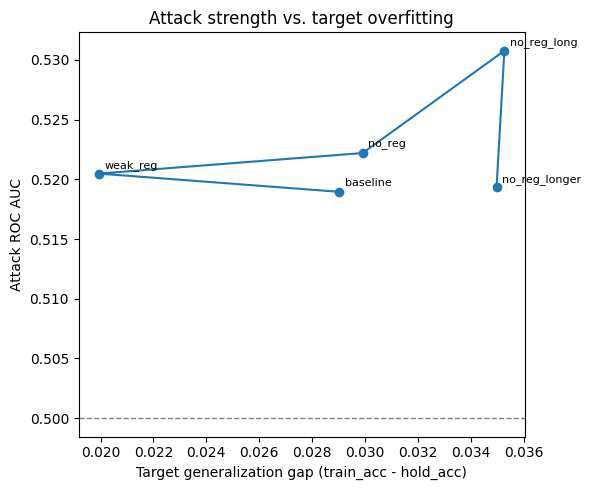


Saved sweep results and chart to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/k_runs/overfit_sweep_20260927_125845


In [9]:
# ==============================================================================
# 8. OVERFITTING SWEEP: does attack AUC track the target's generalization gap?
# ==============================================================================
# The diagnostic showed a ~4.7-point train/held-out accuracy gap, and every
# attack-side improvement (K=5..25, extra features, RF/GB classifiers) has
# plateaued around 0.54 AUC - consistent with Yeom et al.'s result that best
# attack accuracy is bounded by the target's generalization gap. This sweep
# tests that relationship directly: retrain the target (and a smaller set of
# matching shadow models) at increasing levels of deliberate overfitting -
# weaker L1 regularization and more epochs - and measure how attack AUC moves.
#
# NOTE: this changes the TARGET model itself. It is a controlled experiment
# to demonstrate the overfitting -> leakage relationship, not a claim about
# the originally-deployed target model (which stays untouched in k_runs/).
from sklearn.ensemble import RandomForestClassifier

SWEEP_K = 5  # fewer shadow models per level; K has already been shown not to matter much
SWEEP_ROOT = RUN_ROOT / ("overfit_sweep_" + datetime.now().strftime("%Y%m%d_%H%M%S"))

overfit_configs = [
    {"name": "baseline",       "l1_strength": 0.01,  "siamese_epochs": 30},
    {"name": "weak_reg",       "l1_strength": 0.001, "siamese_epochs": 30},
    {"name": "no_reg",         "l1_strength": 0.0,   "siamese_epochs": 30},
    {"name": "no_reg_long",    "l1_strength": 0.0,   "siamese_epochs": 80},
    {"name": "no_reg_longer",  "l1_strength": 0.0,   "siamese_epochs": 150},
]


def build_siamese_network_v2(dim=768, l1_strength=0.01):
    """Same architecture as build_siamese_network, with a tunable activity
    regularizer strength so the degree of overfitting can be controlled.
    l1_strength=0.01 matches the original target/shadow models exactly.
    """
    L = tf.keras.layers
    reg = tf.keras.regularizers.l1(l1_strength) if l1_strength > 0 else None

    enc_in = L.Input(shape=(dim,))
    h = L.LeakyReLU(alpha=0.01)(L.Dense(50, activity_regularizer=reg)(enc_in))
    encoder = tf.keras.Model(enc_in, L.Dense(dim, activation="relu")(h), name="encoder")

    dec_in = L.Input(shape=(dim,))
    decoder = tf.keras.Model(dec_in, L.Dense(dim, activation="sigmoid")(dec_in), name="decoder")

    l_in, r_in = L.Input(shape=(dim,)), L.Input(shape=(dim,))
    siamese = tf.keras.Model([l_in, r_in], L.Concatenate()([decoder(encoder(l_in)), decoder(encoder(r_in))]))

    def contrastive_loss(y_true, y_pred):
        l, r = y_pred[:, :dim], y_pred[:, dim:]
        sq_dist = tf.reduce_sum(tf.square(l - r), axis=1)
        dist = tf.sqrt(tf.maximum(sq_dist, tf.keras.backend.epsilon()))
        y = tf.reshape(tf.cast(y_true, tf.float32), [-1])
        return tf.reduce_mean(
            tf.reduce_mean(tf.square(l - r), axis=1)
            + y * sq_dist + (1.0 - y) * tf.square(tf.maximum(2.5 - dist, 0.0))
        )

    siamese.compile(optimizer="adam", loss=contrastive_loss)

    head = tf.keras.Sequential([
        L.Input(shape=(dim,)),
        L.Dense(64, activation="relu"),
        L.Dense(32, activation="relu"),
        L.Dense(1, activation="sigmoid"),
    ])
    head.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return siamese, encoder, head


def train_and_query_model_v2(x1, x2, y, seed, l1_strength, siamese_epochs, save_dir=None):
    """Same procedure as train_and_query_model, parameterized by regularization
    strength and Siamese epoch count so overfitting severity can be varied.
    """
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    train_idx, hold_idx = train_test_split(
        np.arange(len(y)), test_size=1.0 - TRAIN_RATIO, stratify=y, random_state=seed
    )

    siamese, encoder, head = build_siamese_network_v2(x1.shape[1], l1_strength=l1_strength)

    siamese.fit(
        [x1[train_idx], x2[train_idx]], y[train_idx],
        epochs=siamese_epochs, batch_size=BATCH_SIZE, verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )

    def extract_features(indices):
        e1 = encoder.predict(x1[indices], batch_size=BATCH_SIZE, verbose=0)
        e2 = encoder.predict(x2[indices], batch_size=BATCH_SIZE, verbose=0)
        return np.abs(e1 - e2)

    head.fit(
        extract_features(train_idx), y[train_idx],
        epochs=HEAD_EPOCHS, batch_size=BATCH_SIZE, verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )

    rng = np.random.default_rng(seed)
    n_q = min(int(QUERY_RATIO * len(train_idx)), len(hold_idx))
    member_idx = rng.choice(train_idx, n_q, replace=False)
    non_member_idx = rng.choice(hold_idx, n_q, replace=False)
    query_idx = np.concatenate([member_idx, non_member_idx])
    p_match = head.predict(extract_features(query_idx), batch_size=BATCH_SIZE, verbose=0).ravel()

    df = pd.DataFrame({
        "embedding_row": query_idx,
        "p_match": p_match,
        "linkage_label": y[query_idx],
        "membership": np.r_[np.ones(n_q, dtype=int), np.zeros(n_q, dtype=int)],
    })

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_dir / "membership_outputs.csv", index=False)

    del siamese, encoder, head
    gc.collect()
    return df


def build_attack_features_v2(df):
    p = np.clip(df["p_match"].to_numpy(), 1e-7, 1.0 - 1e-7)
    entropy = -p * np.log(p) - (1.0 - p) * np.log(1.0 - p)
    y = df["linkage_label"].to_numpy()
    raw_loss = -(y * np.log(p) + (1.0 - y) * np.log(1.0 - p))
    return np.column_stack([p, entropy, np.log1p(raw_loss), (p - y) ** 2])


sweep_results = []
for cfg in overfit_configs:
    print(f"\n=== Overfitting level: {cfg['name']} (l1={cfg['l1_strength']}, epochs={cfg['siamese_epochs']}) ===")
    level_dir = SWEEP_ROOT / cfg["name"]

    t_df = train_and_query_model_v2(
        target_x1, target_x2, target_y, seed=SEED,
        l1_strength=cfg["l1_strength"], siamese_epochs=cfg["siamese_epochs"],
        save_dir=level_dir / "target",
    )

    train_p = np.clip(t_df.loc[t_df["membership"] == 1, "p_match"].to_numpy(), 1e-7, 1 - 1e-7)
    train_y = t_df.loc[t_df["membership"] == 1, "linkage_label"].to_numpy()
    hold_p = np.clip(t_df.loc[t_df["membership"] == 0, "p_match"].to_numpy(), 1e-7, 1 - 1e-7)
    hold_y = t_df.loc[t_df["membership"] == 0, "linkage_label"].to_numpy()
    train_acc = float(((train_p >= 0.5).astype(int) == train_y).mean())
    hold_acc = float(((hold_p >= 0.5).astype(int) == hold_y).mean())
    gen_gap = train_acc - hold_acc

    shadow_dfs_level = []
    for k in range(1, SWEEP_K + 1):
        s_df = train_and_query_model_v2(
            shadow_x1, shadow_x2, shadow_y, seed=SEED + k,
            l1_strength=cfg["l1_strength"], siamese_epochs=cfg["siamese_epochs"],
            save_dir=level_dir / f"shadow_{k}",
        )
        shadow_dfs_level.append(s_df)
    shadow_df_level = pd.concat(shadow_dfs_level, ignore_index=True)

    X_tr = build_attack_features_v2(shadow_df_level)
    y_tr = shadow_df_level["membership"].to_numpy()
    X_ev = build_attack_features_v2(t_df)
    y_ev = t_df["membership"].to_numpy()

    attack = RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=50, random_state=SEED)
    attack.fit(X_tr, y_tr)
    attack_scores = attack.predict_proba(X_ev)[:, 1]
    attack_auc = float(roc_auc_score(y_ev, attack_scores))

    print(f"Target train_acc={train_acc:.4f}  hold_acc={hold_acc:.4f}  gen_gap={gen_gap:.4f}  attack_auc={attack_auc:.4f}")
    sweep_results.append({
        "level": cfg["name"], "l1_strength": cfg["l1_strength"], "siamese_epochs": cfg["siamese_epochs"],
        "train_acc": train_acc, "hold_acc": hold_acc, "gen_gap": gen_gap, "attack_auc": attack_auc,
    })

sweep_df = pd.DataFrame(sweep_results)
SWEEP_ROOT.mkdir(parents=True, exist_ok=True)
sweep_df.to_csv(SWEEP_ROOT / "overfit_sweep_results.csv", index=False)

print("\n" + "=" * 60)
print(sweep_df.to_string(index=False))

plt.figure(figsize=(6, 5))
plt.plot(sweep_df["gen_gap"], sweep_df["attack_auc"], "o-")
for _, row in sweep_df.iterrows():
    plt.annotate(row["level"], (row["gen_gap"], row["attack_auc"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Target generalization gap (train_acc - hold_acc)")
plt.ylabel("Attack ROC AUC")
plt.title("Attack strength vs. target overfitting")
plt.tight_layout()
plt.savefig(SWEEP_ROOT / "overfit_sweep_auc_vs_gap.png", dpi=150)
plt.show()

print("\nSaved sweep results and chart to:", SWEEP_ROOT.resolve())



=== bottleneck_dim = 50 ===


2026-09-27 15:09:22.253252: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:10:05.233036: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:10:06.616037: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:10:21.540625: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


train_acc=0.9442  hold_acc=0.8988  gap=0.0454  hold_auc=0.9624  (siamese 44s, head 16s)

=== bottleneck_dim = 128 ===


2026-09-27 15:10:24.261848: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:11:13.307245: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:11:14.189644: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:11:25.482528: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


train_acc=0.9541  hold_acc=0.8992  gap=0.0550  hold_auc=0.9646  (siamese 49s, head 12s)

=== bottleneck_dim = 256 ===


2026-09-27 15:11:27.690953: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:12:18.546711: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:12:19.347936: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:12:30.532975: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


train_acc=0.9608  hold_acc=0.9006  gap=0.0602  hold_auc=0.9630  (siamese 51s, head 11s)

=== bottleneck_dim = 512 ===


2026-09-27 15:12:32.339009: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:13:28.577618: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:13:29.430365: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:13:41.177863: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


train_acc=0.9604  hold_acc=0.8979  gap=0.0625  hold_auc=0.9660  (siamese 56s, head 12s)

 bottleneck_dim  siamese_epochs  siamese_train_time_sec  head_train_time_sec  train_acc  hold_acc  gen_gap  hold_precision  hold_recall  hold_f1  hold_roc_auc
             50              40                    44.1                 15.8   0.944194  0.898761 0.045433        0.891211     0.907952 0.899504      0.962426
            128              40                    49.0                 11.8   0.954150  0.899177 0.054973        0.894205     0.905030 0.899585      0.964573
            256              40                    51.1                 11.5   0.960802  0.900635 0.060166        0.902286     0.898142 0.900209      0.962991
            512              40                    56.5                 12.1   0.960400  0.897927 0.062473        0.931011     0.859111 0.893617      0.965981


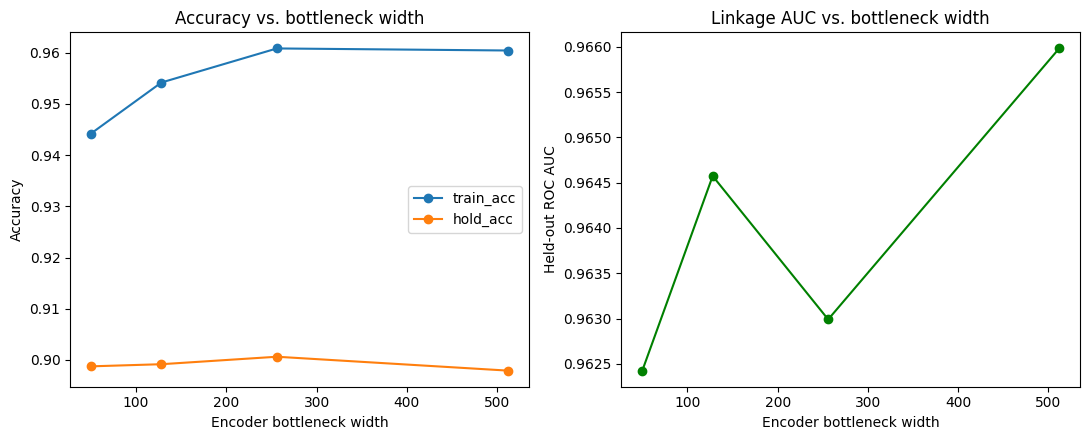


Saved results and chart to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/k_runs/bottleneck_sweep_20260927_151342


In [11]:
# ==============================================================================
# 9. ENCODER BOTTLENECK WIDTH SWEEP (real record-linkage performance)
# ==============================================================================
# Quick tests at 10 epochs showed widening the bottleneck (50 -> 256) made
# train/hold accuracy and AUC WORSE, not better - but that was likely just
# undertraining a larger network in a fixed epoch budget. This sweep uses a
# realistic epoch count (40) per width so each network gets a fair chance to
# converge, and reports the actual linkage metrics (not the MIA attack) so we
# can tell whether bottleneck width is a genuine lever for abstract-matching
# quality, or another dead end like the chunking experiments.
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
import time 

BOTTLENECK_EPOCHS = 40
bottleneck_sizes = [50, 128, 256, 512]

bottleneck_results = []
for bottleneck_dim in bottleneck_sizes:
    print(f"\n=== bottleneck_dim = {bottleneck_dim} ===")
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    train_idx, hold_idx = train_test_split(
        np.arange(len(target_y)), test_size=1.0 - TRAIN_RATIO, stratify=target_y, random_state=SEED
    )

    L = tf.keras.layers
    dim = target_x1.shape[1]
    reg = tf.keras.regularizers.l1(0.01)
    enc_in = L.Input(shape=(dim,))
    h = L.LeakyReLU(alpha=0.01)(L.Dense(bottleneck_dim, activity_regularizer=reg)(enc_in))
    encoder = tf.keras.Model(enc_in, L.Dense(dim, activation="relu")(h), name="encoder")

    dec_in = L.Input(shape=(dim,))
    decoder = tf.keras.Model(dec_in, L.Dense(dim, activation="sigmoid")(dec_in), name="decoder")

    l_in, r_in = L.Input(shape=(dim,)), L.Input(shape=(dim,))
    siamese = tf.keras.Model([l_in, r_in], L.Concatenate()([decoder(encoder(l_in)), decoder(encoder(r_in))]))

    def contrastive_loss(y_true, y_pred):
        l, r = y_pred[:, :dim], y_pred[:, dim:]
        sq_dist = tf.reduce_sum(tf.square(l - r), axis=1)
        dist = tf.sqrt(tf.maximum(sq_dist, tf.keras.backend.epsilon()))
        yt = tf.reshape(tf.cast(y_true, tf.float32), [-1])
        return tf.reduce_mean(
            tf.reduce_mean(tf.square(l - r), axis=1)
            + yt * sq_dist + (1.0 - yt) * tf.square(tf.maximum(2.5 - dist, 0.0))
        )

    siamese.compile(optimizer="adam", loss=contrastive_loss)

    t0 = time.time()
    siamese.fit(
        [target_x1[train_idx], target_x2[train_idx]], target_y[train_idx],
        epochs=BOTTLENECK_EPOCHS, batch_size=BATCH_SIZE, verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )
    siamese_time = time.time() - t0

    head = tf.keras.Sequential([
        L.Input(shape=(dim,)),
        L.Dense(64, activation="relu"),
        L.Dense(32, activation="relu"),
        L.Dense(1, activation="sigmoid"),
    ])
    head.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    def extract_features(indices):
        e1 = encoder.predict(target_x1[indices], batch_size=256, verbose=0)
        e2 = encoder.predict(target_x2[indices], batch_size=256, verbose=0)
        return np.abs(e1 - e2)

    t0 = time.time()
    head.fit(
        extract_features(train_idx), target_y[train_idx],
        epochs=HEAD_EPOCHS, batch_size=BATCH_SIZE, verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )
    head_time = time.time() - t0

    train_pred = head.predict(extract_features(train_idx), batch_size=256, verbose=0).ravel()
    hold_pred = head.predict(extract_features(hold_idx), batch_size=256, verbose=0).ravel()
    train_acc = float(((train_pred >= 0.5).astype(int) == target_y[train_idx]).mean())
    hold_acc = float(((hold_pred >= 0.5).astype(int) == target_y[hold_idx]).mean())
    hold_labels = target_y[hold_idx]
    hold_bin = (hold_pred >= 0.5).astype(int)

    result = {
        "bottleneck_dim": bottleneck_dim,
        "siamese_epochs": BOTTLENECK_EPOCHS,
        "siamese_train_time_sec": round(siamese_time, 1),
        "head_train_time_sec": round(head_time, 1),
        "train_acc": train_acc,
        "hold_acc": hold_acc,
        "gen_gap": train_acc - hold_acc,
        "hold_precision": float(precision_score(hold_labels, hold_bin, zero_division=0)),
        "hold_recall": float(recall_score(hold_labels, hold_bin, zero_division=0)),
        "hold_f1": float(f1_score(hold_labels, hold_bin, zero_division=0)),
        "hold_roc_auc": float(roc_auc_score(hold_labels, hold_pred)),
    }
    print(f"train_acc={train_acc:.4f}  hold_acc={hold_acc:.4f}  gap={result['gen_gap']:.4f}  "
          f"hold_auc={result['hold_roc_auc']:.4f}  (siamese {siamese_time:.0f}s, head {head_time:.0f}s)")
    bottleneck_results.append(result)

    del siamese, encoder, decoder, head
    gc.collect()

bottleneck_df = pd.DataFrame(bottleneck_results)
bottleneck_dir = RUN_ROOT / ("bottleneck_sweep_" + datetime.now().strftime("%Y%m%d_%H%M%S"))
bottleneck_dir.mkdir(parents=True, exist_ok=True)
bottleneck_df.to_csv(bottleneck_dir / "bottleneck_sweep_results.csv", index=False)

print("\n" + "=" * 70)
print(bottleneck_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(bottleneck_df["bottleneck_dim"], bottleneck_df["train_acc"], "o-", label="train_acc")
axes[0].plot(bottleneck_df["bottleneck_dim"], bottleneck_df["hold_acc"], "o-", label="hold_acc")
axes[0].set_xlabel("Encoder bottleneck width")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs. bottleneck width")
axes[0].legend()

axes[1].plot(bottleneck_df["bottleneck_dim"], bottleneck_df["hold_roc_auc"], "o-", color="green")
axes[1].set_xlabel("Encoder bottleneck width")
axes[1].set_ylabel("Held-out ROC AUC")
axes[1].set_title("Linkage AUC vs. bottleneck width")

plt.tight_layout()
plt.savefig(bottleneck_dir / "bottleneck_sweep.png", dpi=150)
plt.show()

print("\nSaved results and chart to:", bottleneck_dir.resolve())



=== baseline (bottleneck=50, l1=0.01, epochs=30) ===


2026-09-27 15:20:13.706016: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:20:38.052841: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:20:39.186961: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:20:47.431946: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:20:50.016689: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:21:12.108875: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:21:12.862134: I tensorflow/core/grappler/optimizers/cust

train_acc=0.9248  hold_acc=0.8958  gen_gap=0.0290  attack_auc=0.5190  (elapsed 4.0 min)

=== wide256_noreg (bottleneck=256, l1=0.0, epochs=40) ===


2026-09-27 15:24:11.010306: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:24:44.242924: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:24:44.981660: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:24:53.109811: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:24:54.080684: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:25:30.790127: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:25:31.581402: I tensorflow/core/grappler/optimizers/cust

train_acc=0.9634  hold_acc=0.9165  gen_gap=0.0469  attack_auc=0.5397  (elapsed 4.7 min)

=== wide512_noreg (bottleneck=512, l1=0.0, epochs=40) ===


...

train_acc=0.9735  hold_acc=0.9146  gen_gap=0.0589  attack_auc=0.5576  (elapsed 5.0 min)

=== wide512_noreg_long (bottleneck=512, l1=0.0, epochs=80) ===


2026-09-27 15:33:54.996204: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:35:01.069097: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:35:01.960864: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:35:10.372360: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:35:11.523568: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:36:19.038038: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:36:19.913773: I tensorflow/core/grappler/optimizers/cust

train_acc=0.9597  hold_acc=0.8897  gen_gap=0.0700  attack_auc=0.5738  (elapsed 8.3 min)

=== wide512_noreg_longer (bottleneck=512, l1=0.0, epochs=150) ===


2026-09-27 15:42:15.587707: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:44:24.859562: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:44:25.859841: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:44:35.190501: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:44:36.460780: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:46:49.115749: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 15:46:50.009702: I tensorflow/core/grappler/optimizers/cust

train_acc=0.9490  hold_acc=0.8708  gen_gap=0.0781  attack_auc=0.5688  (elapsed 14.6 min)

               level  bottleneck_dim  l1_strength  siamese_epochs  train_acc  hold_acc  gen_gap  attack_auc  elapsed_min
            baseline              50         0.01              30   0.924840  0.895818 0.029022    0.518951          4.0
       wide256_noreg             256         0.00              40   0.963387  0.916505 0.046882    0.539733          4.7
       wide512_noreg             512         0.00              40   0.973508  0.914571 0.058937    0.557594          5.0
  wide512_noreg_long             512         0.00              80   0.959667  0.889716 0.069951    0.573838          8.3
wide512_noreg_longer             512         0.00             150   0.948951  0.870814 0.078137    0.568811         14.6


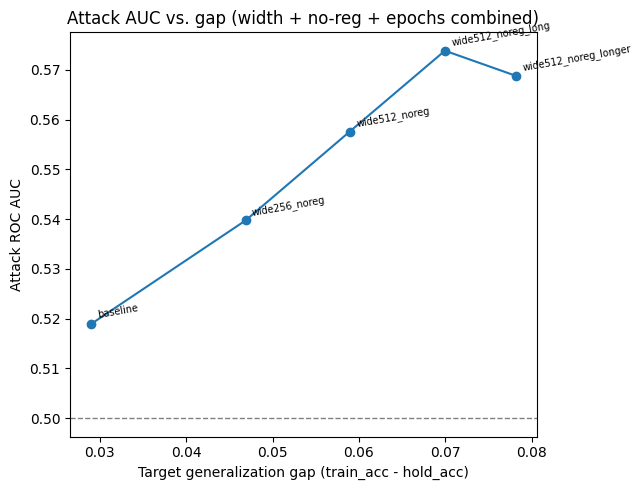


Saved sweep results and chart to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/k_runs/mia_bottleneck_sweep_20260927_152011


In [12]:
# ==============================================================================
# 10. COMBINED OVERFITTING LEVER: bottleneck width x no-regularization x epochs
# ==============================================================================
# Two separate findings now combine into one lever for the MIA side:
#   - Section 8 (l1/epochs sweep): gen_gap moved 0.020 -> 0.035, weak/noisy.
#   - Section 9 (width sweep): gen_gap moved 0.045 -> 0.062, cleanly and
#     monotonically with width, at only 40 epochs and with L1 still on.
# This sweep removes the L1 regularizer entirely AND widens the bottleneck
# AND extends epochs, stacking all three levers to push the target's
# generalization gap - and therefore attack AUC - as far as practical.
# Shadow models are retrained identically to the target at each level, same
# as section 8, since the shadow-attack assumption requires matched behavior.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import time

SWEEP_K = 5
MIA_SWEEP_ROOT = RUN_ROOT / ("mia_bottleneck_sweep_" + datetime.now().strftime("%Y%m%d_%H%M%S"))

mia_configs = [
    {"name": "baseline",             "bottleneck_dim": 50,  "l1_strength": 0.01, "epochs": 30},
    {"name": "wide256_noreg",        "bottleneck_dim": 256, "l1_strength": 0.0,  "epochs": 40},
    {"name": "wide512_noreg",        "bottleneck_dim": 512, "l1_strength": 0.0,  "epochs": 40},
    {"name": "wide512_noreg_long",   "bottleneck_dim": 512, "l1_strength": 0.0,  "epochs": 80},
    {"name": "wide512_noreg_longer", "bottleneck_dim": 512, "l1_strength": 0.0,  "epochs": 150},
]


def build_siamese_network_v3(dim=768, bottleneck_dim=50, l1_strength=0.01):
    L = tf.keras.layers
    reg = tf.keras.regularizers.l1(l1_strength) if l1_strength > 0 else None

    enc_in = L.Input(shape=(dim,))
    h = L.LeakyReLU(alpha=0.01)(L.Dense(bottleneck_dim, activity_regularizer=reg)(enc_in))
    encoder = tf.keras.Model(enc_in, L.Dense(dim, activation="relu")(h), name="encoder")

    dec_in = L.Input(shape=(dim,))
    decoder = tf.keras.Model(dec_in, L.Dense(dim, activation="sigmoid")(dec_in), name="decoder")

    l_in, r_in = L.Input(shape=(dim,)), L.Input(shape=(dim,))
    siamese = tf.keras.Model([l_in, r_in], L.Concatenate()([decoder(encoder(l_in)), decoder(encoder(r_in))]))

    def contrastive_loss(y_true, y_pred):
        l, r = y_pred[:, :dim], y_pred[:, dim:]
        sq_dist = tf.reduce_sum(tf.square(l - r), axis=1)
        dist = tf.sqrt(tf.maximum(sq_dist, tf.keras.backend.epsilon()))
        yt = tf.reshape(tf.cast(y_true, tf.float32), [-1])
        return tf.reduce_mean(
            tf.reduce_mean(tf.square(l - r), axis=1)
            + yt * sq_dist + (1.0 - yt) * tf.square(tf.maximum(2.5 - dist, 0.0))
        )

    siamese.compile(optimizer="adam", loss=contrastive_loss)

    head = tf.keras.Sequential([
        L.Input(shape=(dim,)),
        L.Dense(64, activation="relu"),
        L.Dense(32, activation="relu"),
        L.Dense(1, activation="sigmoid"),
    ])
    head.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return siamese, encoder, head


def train_and_query_model_v3(x1, x2, y, seed, bottleneck_dim, l1_strength, siamese_epochs, save_dir=None):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    train_idx, hold_idx = train_test_split(
        np.arange(len(y)), test_size=1.0 - TRAIN_RATIO, stratify=y, random_state=seed
    )

    siamese, encoder, head = build_siamese_network_v3(
        x1.shape[1], bottleneck_dim=bottleneck_dim, l1_strength=l1_strength
    )

    siamese.fit(
        [x1[train_idx], x2[train_idx]], y[train_idx],
        epochs=siamese_epochs, batch_size=BATCH_SIZE, verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )

    def extract_features(indices):
        e1 = encoder.predict(x1[indices], batch_size=256, verbose=0)
        e2 = encoder.predict(x2[indices], batch_size=256, verbose=0)
        return np.abs(e1 - e2)

    head.fit(
        extract_features(train_idx), y[train_idx],
        epochs=HEAD_EPOCHS, batch_size=BATCH_SIZE, verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )

    rng = np.random.default_rng(seed)
    n_q = min(int(QUERY_RATIO * len(train_idx)), len(hold_idx))
    member_idx = rng.choice(train_idx, n_q, replace=False)
    non_member_idx = rng.choice(hold_idx, n_q, replace=False)
    query_idx = np.concatenate([member_idx, non_member_idx])
    p_match = head.predict(extract_features(query_idx), batch_size=256, verbose=0).ravel()

    df = pd.DataFrame({
        "embedding_row": query_idx,
        "p_match": p_match,
        "linkage_label": y[query_idx],
        "membership": np.r_[np.ones(n_q, dtype=int), np.zeros(n_q, dtype=int)],
    })

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_dir / "membership_outputs.csv", index=False)

    del siamese, encoder, head
    gc.collect()
    return df


def build_attack_features_v3(df):
    p = np.clip(df["p_match"].to_numpy(), 1e-7, 1.0 - 1e-7)
    entropy = -p * np.log(p) - (1.0 - p) * np.log(1.0 - p)
    y = df["linkage_label"].to_numpy()
    raw_loss = -(y * np.log(p) + (1.0 - y) * np.log(1.0 - p))
    return np.column_stack([p, entropy, np.log1p(raw_loss), (p - y) ** 2])


mia_sweep_results = []
for cfg in mia_configs:
    t_cfg = time.time()
    print(f"\n=== {cfg['name']} (bottleneck={cfg['bottleneck_dim']}, l1={cfg['l1_strength']}, epochs={cfg['epochs']}) ===")
    level_dir = MIA_SWEEP_ROOT / cfg["name"]

    t_df = train_and_query_model_v3(
        target_x1, target_x2, target_y, seed=SEED,
        bottleneck_dim=cfg["bottleneck_dim"], l1_strength=cfg["l1_strength"], siamese_epochs=cfg["epochs"],
        save_dir=level_dir / "target",
    )

    train_p = np.clip(t_df.loc[t_df["membership"] == 1, "p_match"].to_numpy(), 1e-7, 1 - 1e-7)
    train_y = t_df.loc[t_df["membership"] == 1, "linkage_label"].to_numpy()
    hold_p = np.clip(t_df.loc[t_df["membership"] == 0, "p_match"].to_numpy(), 1e-7, 1 - 1e-7)
    hold_y = t_df.loc[t_df["membership"] == 0, "linkage_label"].to_numpy()
    train_acc = float(((train_p >= 0.5).astype(int) == train_y).mean())
    hold_acc = float(((hold_p >= 0.5).astype(int) == hold_y).mean())
    gen_gap = train_acc - hold_acc

    shadow_dfs_level = []
    for k in range(1, SWEEP_K + 1):
        s_df = train_and_query_model_v3(
            shadow_x1, shadow_x2, shadow_y, seed=SEED + k,
            bottleneck_dim=cfg["bottleneck_dim"], l1_strength=cfg["l1_strength"], siamese_epochs=cfg["epochs"],
            save_dir=level_dir / f"shadow_{k}",
        )
        shadow_dfs_level.append(s_df)
    shadow_df_level = pd.concat(shadow_dfs_level, ignore_index=True)

    X_tr = build_attack_features_v3(shadow_df_level)
    y_tr = shadow_df_level["membership"].to_numpy()
    X_ev = build_attack_features_v3(t_df)
    y_ev = t_df["membership"].to_numpy()

    attack = RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=50, random_state=SEED)
    attack.fit(X_tr, y_tr)
    attack_scores = attack.predict_proba(X_ev)[:, 1]
    attack_auc = float(roc_auc_score(y_ev, attack_scores))

    elapsed = time.time() - t_cfg
    print(f"train_acc={train_acc:.4f}  hold_acc={hold_acc:.4f}  gen_gap={gen_gap:.4f}  "
          f"attack_auc={attack_auc:.4f}  (elapsed {elapsed/60:.1f} min)")
    mia_sweep_results.append({
        "level": cfg["name"], "bottleneck_dim": cfg["bottleneck_dim"],
        "l1_strength": cfg["l1_strength"], "siamese_epochs": cfg["epochs"],
        "train_acc": train_acc, "hold_acc": hold_acc, "gen_gap": gen_gap, "attack_auc": attack_auc,
        "elapsed_min": round(elapsed / 60, 1),
    })

mia_sweep_df = pd.DataFrame(mia_sweep_results)
MIA_SWEEP_ROOT.mkdir(parents=True, exist_ok=True)
mia_sweep_df.to_csv(MIA_SWEEP_ROOT / "mia_bottleneck_sweep_results.csv", index=False)

print("\n" + "=" * 70)
print(mia_sweep_df.to_string(index=False))

plt.figure(figsize=(6.5, 5))
plt.plot(mia_sweep_df["gen_gap"], mia_sweep_df["attack_auc"], "o-")
for _, row in mia_sweep_df.iterrows():
    plt.annotate(row["level"], (row["gen_gap"], row["attack_auc"]), fontsize=7,
                 xytext=(4, 4), textcoords="offset points", rotation=10)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Target generalization gap (train_acc - hold_acc)")
plt.ylabel("Attack ROC AUC")
plt.title("Attack AUC vs. gap (width + no-reg + epochs combined)")
plt.tight_layout()
plt.savefig(MIA_SWEEP_ROOT / "mia_bottleneck_sweep.png", dpi=150)
plt.show()

print("\nSaved sweep results and chart to:", MIA_SWEEP_ROOT.resolve())



=== wide1024_noreg_40ep (bottleneck=1024, l1=0.0, epochs=40) ===


2026-09-27 18:26:00.461635: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:26:34.516241: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:26:35.566067: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:26:44.056976: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:26:45.579056: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:27:21.245555: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:27:22.660169: I tensorflow/core/grappler/optimizers/cust

train_acc=0.9626  hold_acc=0.9052  gen_gap=0.0574  attack_auc=0.5530  (elapsed 5.3 min)

=== wide2048_noreg_40ep (bottleneck=2048, l1=0.0, epochs=40) ===


2026-09-27 18:31:13.712507: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:32:05.729763: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:32:07.067714: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:32:16.278907: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:32:17.532983: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:33:13.080673: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:33:14.222916: I tensorflow/core/grappler/optimizers/cust

train_acc=0.9537  hold_acc=0.8961  gen_gap=0.0576  attack_auc=0.5464  (elapsed 7.0 min)

               level  bottleneck_dim  l1_strength  siamese_epochs  train_acc  hold_acc  gen_gap  attack_auc  elapsed_min
            baseline              50         0.01              30   0.924840  0.895818 0.029022    0.518951          4.0
       wide256_noreg             256         0.00              40   0.963387  0.916505 0.046882    0.539733          4.7
       wide512_noreg             512         0.00              40   0.973508  0.914571 0.058937    0.557594          5.0
  wide512_noreg_long             512         0.00              80   0.959667  0.889716 0.069951    0.573838          8.3
wide512_noreg_longer             512         0.00             150   0.948951  0.870814 0.078137    0.568811         14.6
 wide1024_noreg_40ep            1024         0.00              40   0.962643  0.905194 0.057449    0.553004          5.3
 wide2048_noreg_40ep            2048         0.00              4

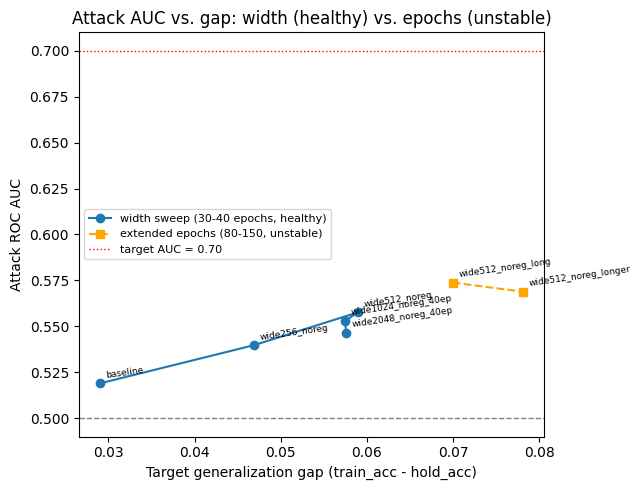


Saved updated results and chart to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/k_runs/mia_bottleneck_sweep_20260927_152011


In [13]:
# ==============================================================================
# 11. PUSH WIDTH FURTHER AT FIXED 40 EPOCHS (avoid the 150-epoch instability zone)
# ==============================================================================
# Section 10 showed width is a clean, monotonic lever at 40 epochs (gap 0.029
# -> 0.059, AUC 0.519 -> 0.558), but epochs beyond ~80 caused BOTH train_acc
# and hold_acc to fall together (training instability, not real memorization),
# which dragged AUC back down. This cell keeps epochs fixed at the "healthy"
# 40-epoch point and pushes width further (1024, 2048) instead, to see if the
# gap can keep climbing toward the ~0.165 needed for 0.70 AUC without hitting
# that instability wall.
# Reuses build_siamese_network_v3 / train_and_query_model_v3 /
# build_attack_features_v3 / mia_sweep_results / MIA_SWEEP_ROOT from section 10
# - run this in the same notebook session, after that cell has completed.

further_width_configs = [
    {"name": "wide1024_noreg_40ep", "bottleneck_dim": 1024, "l1_strength": 0.0, "epochs": 40},
    {"name": "wide2048_noreg_40ep", "bottleneck_dim": 2048, "l1_strength": 0.0, "epochs": 40},
]

for cfg in further_width_configs:
    t_cfg = time.time()
    print(f"\n=== {cfg['name']} (bottleneck={cfg['bottleneck_dim']}, l1={cfg['l1_strength']}, epochs={cfg['epochs']}) ===")
    level_dir = MIA_SWEEP_ROOT / cfg["name"]

    t_df = train_and_query_model_v3(
        target_x1, target_x2, target_y, seed=SEED,
        bottleneck_dim=cfg["bottleneck_dim"], l1_strength=cfg["l1_strength"], siamese_epochs=cfg["epochs"],
        save_dir=level_dir / "target",
    )

    train_p = np.clip(t_df.loc[t_df["membership"] == 1, "p_match"].to_numpy(), 1e-7, 1 - 1e-7)
    train_y = t_df.loc[t_df["membership"] == 1, "linkage_label"].to_numpy()
    hold_p = np.clip(t_df.loc[t_df["membership"] == 0, "p_match"].to_numpy(), 1e-7, 1 - 1e-7)
    hold_y = t_df.loc[t_df["membership"] == 0, "linkage_label"].to_numpy()
    train_acc = float(((train_p >= 0.5).astype(int) == train_y).mean())
    hold_acc = float(((hold_p >= 0.5).astype(int) == hold_y).mean())
    gen_gap = train_acc - hold_acc

    shadow_dfs_level = []
    for k in range(1, SWEEP_K + 1):
        s_df = train_and_query_model_v3(
            shadow_x1, shadow_x2, shadow_y, seed=SEED + k,
            bottleneck_dim=cfg["bottleneck_dim"], l1_strength=cfg["l1_strength"], siamese_epochs=cfg["epochs"],
            save_dir=level_dir / f"shadow_{k}",
        )
        shadow_dfs_level.append(s_df)
    shadow_df_level = pd.concat(shadow_dfs_level, ignore_index=True)

    X_tr = build_attack_features_v3(shadow_df_level)
    y_tr = shadow_df_level["membership"].to_numpy()
    X_ev = build_attack_features_v3(t_df)
    y_ev = t_df["membership"].to_numpy()

    attack = RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=50, random_state=SEED)
    attack.fit(X_tr, y_tr)
    attack_scores = attack.predict_proba(X_ev)[:, 1]
    attack_auc = float(roc_auc_score(y_ev, attack_scores))

    elapsed = time.time() - t_cfg
    print(f"train_acc={train_acc:.4f}  hold_acc={hold_acc:.4f}  gen_gap={gen_gap:.4f}  "
          f"attack_auc={attack_auc:.4f}  (elapsed {elapsed/60:.1f} min)")
    mia_sweep_results.append({
        "level": cfg["name"], "bottleneck_dim": cfg["bottleneck_dim"],
        "l1_strength": cfg["l1_strength"], "siamese_epochs": cfg["epochs"],
        "train_acc": train_acc, "hold_acc": hold_acc, "gen_gap": gen_gap, "attack_auc": attack_auc,
        "elapsed_min": round(elapsed / 60, 1),
    })

mia_sweep_df = pd.DataFrame(mia_sweep_results)
mia_sweep_df.to_csv(MIA_SWEEP_ROOT / "mia_bottleneck_sweep_results.csv", index=False)

print("\n" + "=" * 70)
print(mia_sweep_df.to_string(index=False))

fixed_epoch_mask = mia_sweep_df["siamese_epochs"].isin([30, 40])
plt.figure(figsize=(6.5, 5))
plt.plot(mia_sweep_df.loc[fixed_epoch_mask, "gen_gap"], mia_sweep_df.loc[fixed_epoch_mask, "attack_auc"], "o-", label="width sweep (30-40 epochs, healthy)")
plt.plot(mia_sweep_df.loc[~fixed_epoch_mask, "gen_gap"], mia_sweep_df.loc[~fixed_epoch_mask, "attack_auc"], "s--", color="orange", label="extended epochs (80-150, unstable)")
for _, row in mia_sweep_df.iterrows():
    plt.annotate(row["level"], (row["gen_gap"], row["attack_auc"]), fontsize=6.5,
                 xytext=(4, 4), textcoords="offset points", rotation=8)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.axhline(0.70, color="red", linestyle=":", linewidth=1, label="target AUC = 0.70")
plt.xlabel("Target generalization gap (train_acc - hold_acc)")
plt.ylabel("Attack ROC AUC")
plt.title("Attack AUC vs. gap: width (healthy) vs. epochs (unstable)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(MIA_SWEEP_ROOT / "mia_bottleneck_sweep_extended.png", dpi=150)
plt.show()

print("\nSaved updated results and chart to:", MIA_SWEEP_ROOT.resolve())



=== train_subset_size = 22400 ===


2026-09-27 18:44:50.499082: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:45:21.599071: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:45:22.908027: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:45:31.508187: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:45:33.709813: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:46:08.842963: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:46:09.717124: I tensorflow/core/grappler/optimizers/cust

train_acc=0.9689  hold_acc=0.9100  gen_gap=0.0589  attack_auc=0.5477  n_query_per_class=6719  (elapsed 5.1 min)

=== train_subset_size = 8000 ===


2026-09-27 18:49:53.605433: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:50:08.907668: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:50:09.699170: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:50:14.272605: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:50:15.361186: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:50:31.503203: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:50:32.228656: I tensorflow/core/grappler/optimizers/cust

train_acc=0.9912  hold_acc=0.8954  gen_gap=0.0958  attack_auc=0.6070  n_query_per_class=2400  (elapsed 2.3 min)

=== train_subset_size = 4000 ===


...

train_acc=0.9917  hold_acc=0.8633  gen_gap=0.1283  attack_auc=0.7003  n_query_per_class=600  (elapsed 0.9 min)

=== train_subset_size = 1000 ===


2026-09-27 18:54:38.534446: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:54:42.262559: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:54:42.602561: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:54:43.925980: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:54:44.790579: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:54:48.446385: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:54:48.792692: I tensorflow/core/grappler/optimizers/cust

train_acc=1.0000  hold_acc=0.8433  gen_gap=0.1567  attack_auc=0.6795  n_query_per_class=300  (elapsed 0.6 min)

=== train_subset_size = 500 ===


2026-09-27 18:55:16.026171: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:55:19.140695: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:55:19.470937: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:55:20.638615: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:55:21.600961: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:55:24.253723: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 18:55:24.738750: I tensorflow/core/grappler/optimizers/cust

train_acc=0.9600  hold_acc=0.7800  gen_gap=0.1800  attack_auc=0.6138  n_query_per_class=150  (elapsed 0.5 min)

 train_subset_size  bottleneck_dim  epochs  train_acc  hold_acc  gen_gap  attack_auc  elapsed_min
             22400             512      40   0.968894  0.909957 0.058937    0.547685          5.1
              8000             512      40   0.991250  0.895417 0.095833    0.606994          2.3
              4000             512      40   0.995000  0.869167 0.125833    0.651617          1.6
              2000             512      40   0.991667  0.863333 0.128333    0.700296          0.9
              1000             512      40   1.000000  0.843333 0.156667    0.679494          0.6
               500             512      40   0.960000  0.780000 0.180000    0.613800          0.5


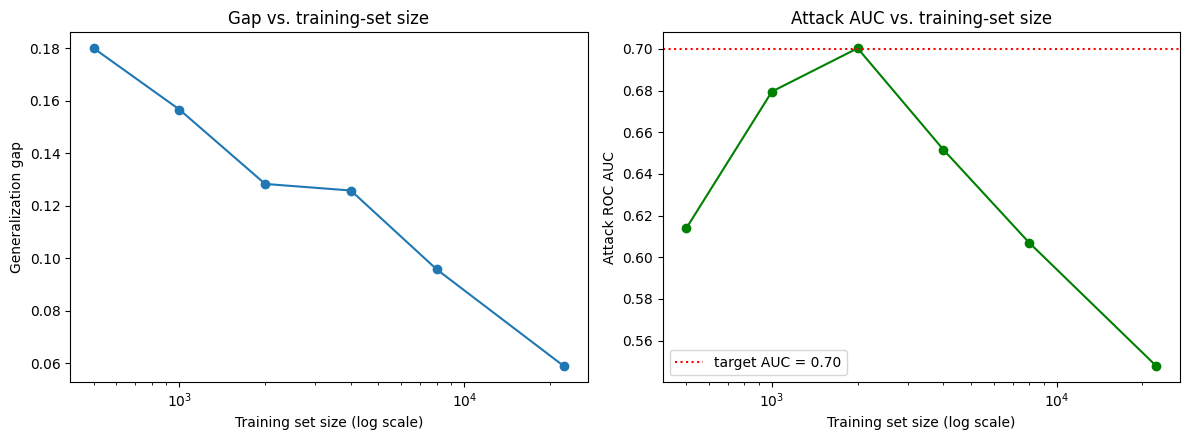


Saved results and chart to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/k_runs/train_size_sweep_20260927_184447


In [14]:
# ==============================================================================
# 12. TRAINING-SET SIZE SWEEP (the strongest classical overfitting lever)
# ==============================================================================
# Width plateaued at 512 (no further gap growth from 1024/2048), and pushing
# epochs past ~80 caused general training instability rather than clean
# memorization. This sweep holds architecture fixed at the best config found
# so far (bottleneck=512, no L1, 40 epochs) and instead shrinks the TRAINING
# SET SIZE - classically the single strongest driver of generalization gap,
# since a fixed-capacity model has proportionally more room to memorize a
# smaller training set. The held-out evaluation set is kept large and FIXED
# across all sizes (same 30% hold-out every time) so hold_acc stays a stable,
# comparable measurement; only what the model gets to train ON shrinks.

BEST_BOTTLENECK = 512
BEST_L1 = 0.0
BEST_EPOCHS = 40
TRAIN_SIZE_SWEEP_ROOT = RUN_ROOT / ("train_size_sweep_" + datetime.now().strftime("%Y%m%d_%H%M%S"))

train_sizes = [22400, 8000, 4000, 2000, 1000, 500]


def train_and_query_model_subset(x1, x2, y, seed, bottleneck_dim, l1_strength, siamese_epochs,
                                  train_subset_size, save_dir=None):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    # Fixed 70/30 split first, so the held-out set is identical across sweep sizes
    full_train_idx, hold_idx = train_test_split(
        np.arange(len(y)), test_size=1.0 - TRAIN_RATIO, stratify=y, random_state=seed
    )
    # Then subsample the TRAINING portion down to train_subset_size
    rng = np.random.default_rng(seed)
    n = min(train_subset_size, len(full_train_idx))
    train_idx = rng.choice(full_train_idx, size=n, replace=False)

    siamese, encoder, head = build_siamese_network_v3(
        x1.shape[1], bottleneck_dim=bottleneck_dim, l1_strength=l1_strength
    )
    siamese.fit(
        [x1[train_idx], x2[train_idx]], y[train_idx],
        epochs=siamese_epochs, batch_size=min(BATCH_SIZE, n), verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )

    def extract_features(indices):
        e1 = encoder.predict(x1[indices], batch_size=256, verbose=0)
        e2 = encoder.predict(x2[indices], batch_size=256, verbose=0)
        return np.abs(e1 - e2)

    head.fit(
        extract_features(train_idx), y[train_idx],
        epochs=HEAD_EPOCHS, batch_size=min(BATCH_SIZE, n), verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )

    n_q = min(int(QUERY_RATIO * n), len(hold_idx), n)
    member_idx = rng.choice(train_idx, n_q, replace=False)
    non_member_idx = rng.choice(hold_idx, n_q, replace=False)
    query_idx = np.concatenate([member_idx, non_member_idx])
    p_match = head.predict(extract_features(query_idx), batch_size=256, verbose=0).ravel()

    df = pd.DataFrame({
        "embedding_row": query_idx,
        "p_match": p_match,
        "linkage_label": y[query_idx],
        "membership": np.r_[np.ones(n_q, dtype=int), np.zeros(n_q, dtype=int)],
    })

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_dir / "membership_outputs.csv", index=False)

    del siamese, encoder, head
    gc.collect()
    return df


train_size_results = []
for n in train_sizes:
    t_cfg = time.time()
    print(f"\n=== train_subset_size = {n} ===")
    level_dir = TRAIN_SIZE_SWEEP_ROOT / f"n{n}"

    t_df = train_and_query_model_subset(
        target_x1, target_x2, target_y, seed=SEED,
        bottleneck_dim=BEST_BOTTLENECK, l1_strength=BEST_L1, siamese_epochs=BEST_EPOCHS,
        train_subset_size=n, save_dir=level_dir / "target",
    )

    train_p = np.clip(t_df.loc[t_df["membership"] == 1, "p_match"].to_numpy(), 1e-7, 1 - 1e-7)
    train_y = t_df.loc[t_df["membership"] == 1, "linkage_label"].to_numpy()
    hold_p = np.clip(t_df.loc[t_df["membership"] == 0, "p_match"].to_numpy(), 1e-7, 1 - 1e-7)
    hold_y = t_df.loc[t_df["membership"] == 0, "linkage_label"].to_numpy()
    train_acc = float(((train_p >= 0.5).astype(int) == train_y).mean())
    hold_acc = float(((hold_p >= 0.5).astype(int) == hold_y).mean())
    gen_gap = train_acc - hold_acc

    shadow_dfs_level = []
    for k in range(1, SWEEP_K + 1):
        s_df = train_and_query_model_subset(
            shadow_x1, shadow_x2, shadow_y, seed=SEED + k,
            bottleneck_dim=BEST_BOTTLENECK, l1_strength=BEST_L1, siamese_epochs=BEST_EPOCHS,
            train_subset_size=n, save_dir=level_dir / f"shadow_{k}",
        )
        shadow_dfs_level.append(s_df)
    shadow_df_level = pd.concat(shadow_dfs_level, ignore_index=True)

    X_tr = build_attack_features_v3(shadow_df_level)
    y_tr = shadow_df_level["membership"].to_numpy()
    X_ev = build_attack_features_v3(t_df)
    y_ev = t_df["membership"].to_numpy()

    attack = RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=max(5, n // 100), random_state=SEED)
    attack.fit(X_tr, y_tr)
    attack_scores = attack.predict_proba(X_ev)[:, 1]
    attack_auc = float(roc_auc_score(y_ev, attack_scores))

    elapsed = time.time() - t_cfg
    print(f"train_acc={train_acc:.4f}  hold_acc={hold_acc:.4f}  gen_gap={gen_gap:.4f}  "
          f"attack_auc={attack_auc:.4f}  n_query_per_class={len(train_p)}  (elapsed {elapsed/60:.1f} min)")
    train_size_results.append({
        "train_subset_size": n, "bottleneck_dim": BEST_BOTTLENECK, "epochs": BEST_EPOCHS,
        "train_acc": train_acc, "hold_acc": hold_acc, "gen_gap": gen_gap, "attack_auc": attack_auc,
        "elapsed_min": round(elapsed / 60, 1),
    })

train_size_df = pd.DataFrame(train_size_results)
TRAIN_SIZE_SWEEP_ROOT.mkdir(parents=True, exist_ok=True)
train_size_df.to_csv(TRAIN_SIZE_SWEEP_ROOT / "train_size_sweep_results.csv", index=False)

print("\n" + "=" * 70)
print(train_size_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(train_size_df["train_subset_size"], train_size_df["gen_gap"], "o-")
axes[0].set_xscale("log")
axes[0].set_xlabel("Training set size (log scale)")
axes[0].set_ylabel("Generalization gap")
axes[0].set_title("Gap vs. training-set size")

axes[1].plot(train_size_df["train_subset_size"], train_size_df["attack_auc"], "o-", color="green")
axes[1].axhline(0.70, color="red", linestyle=":", label="target AUC = 0.70")
axes[1].set_xscale("log")
axes[1].set_xlabel("Training set size (log scale)")
axes[1].set_ylabel("Attack ROC AUC")
axes[1].set_title("Attack AUC vs. training-set size")
axes[1].legend()

plt.tight_layout()
plt.savefig(TRAIN_SIZE_SWEEP_ROOT / "train_size_sweep.png", dpi=150)
plt.show()

print("\nSaved results and chart to:", TRAIN_SIZE_SWEEP_ROOT.resolve())


Training pool size: 22399 | block size: 2000 | number of blocks: 12
Block sizes: [2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 399]
Union of all blocks covers full pool: True

=== block 1/12  (n=2000) ===


2026-09-27 19:16:53.263885: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:16:59.655083: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:17:00.670748: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:17:02.795100: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:17:05.415504: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:17:13.602299: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:17:14.132940: I tensorflow/core/grappler/optimizers/cust

train_acc=0.9950  hold_acc=0.8317  gen_gap=0.1633  attack_auc=0.7014  (elapsed 1.2 min)

=== block 2/12  (n=2000) ===


2026-09-27 19:18:05.950241: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:18:14.067695: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:18:15.130818: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:18:18.007394: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:18:19.074965: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:18:27.421540: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:18:28.287323: I tensorflow/core/grappler/optimizers/cust

train_acc=0.9983  hold_acc=0.8600  gen_gap=0.1383  attack_auc=0.6943  (elapsed 1.2 min)

=== block 3/12  (n=2000) ===


...

train_acc=0.9933  hold_acc=0.8117  gen_gap=0.1817  attack_auc=0.6886  (elapsed 2.1 min)

=== block 11/12  (n=2000) ===


2026-09-27 19:30:21.756454: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:30:30.147128: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:30:31.205075: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:30:34.323847: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:30:35.495360: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:30:44.785472: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:30:45.503966: I tensorflow/core/grappler/optimizers/cust

train_acc=0.9967  hold_acc=0.8367  gen_gap=0.1600  attack_auc=0.7004  (elapsed 1.4 min)

=== block 12/12  (n=399) ===


2026-09-27 19:31:45.740564: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:31:51.654420: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:31:52.349849: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:31:55.793839: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:31:57.063399: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:32:07.400869: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:32:08.147550: I tensorflow/core/grappler/optimizers/cust

train_acc=0.9244  hold_acc=0.7815  gen_gap=0.1429  attack_auc=0.6098  (elapsed 1.5 min)

 block  n_train  train_acc  hold_acc  gen_gap  attack_auc  elapsed_min
     1     2000   0.995000  0.831667 0.163333    0.701408          1.2
     2     2000   0.998333  0.860000 0.138333    0.694311          1.2
     3     2000   0.998333  0.840000 0.158333    0.713365          1.0
     4     2000   0.996667  0.855000 0.141667    0.721696          1.2
     5     2000   0.993333  0.825000 0.168333    0.695140          1.2
     6     2000   0.993333  0.848333 0.145000    0.670069          1.2
     7     2000   1.000000  0.823333 0.176667    0.716517          1.3
     8     2000   0.998333  0.825000 0.173333    0.687219          1.3
     9     2000   0.996667  0.826667 0.170000    0.722836          1.8
    10     2000   0.993333  0.811667 0.181667    0.688606          2.1
    11     2000   0.996667  0.836667 0.160000    0.700369          1.4
    12      399   0.924370  0.781513 0.142857    0.609809  

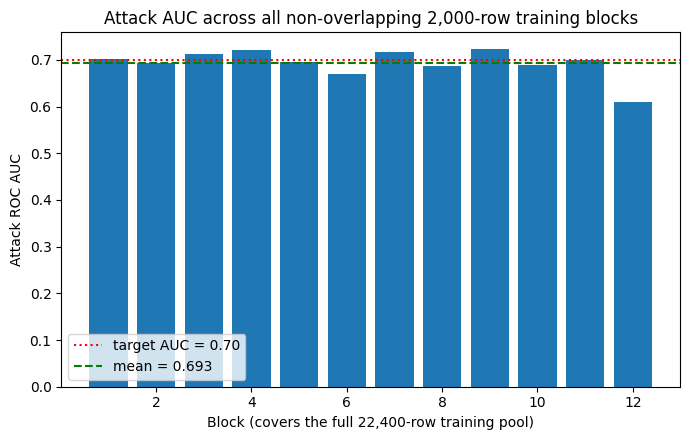


Saved results and chart to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/k_runs/block_coverage_sweep_20260927_191651


In [15]:
# ==============================================================================
# 13. BLOCK-COVERAGE SWEEP at train_subset_size=2000
# ==============================================================================
# The 0.700 result came from ONE random 2000-row draw out of the 22,400-row
# training pool. This cell instead partitions the entire pool into
# non-overlapping blocks of 2000 rows and trains a full target+shadow attack
# pipeline on EACH block in turn. By the time all blocks finish, every row in
# the training pool has been used for training in exactly one block (full
# coverage, no row skipped and no row reused) - and we get a distribution of
# gen_gap/attack_auc across blocks instead of a single point estimate, so we
# can tell whether 0.700 is typical or was a favorable outlier.
# The held-out set stays completely fixed and untouched by training in every
# block, exactly as before - only the training-pool partitioning changes.

BLOCK_BOTTLENECK = 512
BLOCK_L1 = 0.0
BLOCK_EPOCHS = 40
BLOCK_SIZE = 2000
BLOCK_SWEEP_ROOT = RUN_ROOT / ("block_coverage_sweep_" + datetime.now().strftime("%Y%m%d_%H%M%S"))

# Recreate the SAME fixed 70/30 split used throughout (identical to every earlier sweep)
full_train_idx, hold_idx = train_test_split(
    np.arange(len(target_y)), test_size=1.0 - TRAIN_RATIO, stratify=target_y, random_state=SEED
)

# Shuffle once (reproducibly), then slice into consecutive, non-overlapping blocks
block_rng = np.random.default_rng(SEED)
shuffled_pool = block_rng.permutation(full_train_idx)
blocks = [shuffled_pool[i:i + BLOCK_SIZE] for i in range(0, len(shuffled_pool), BLOCK_SIZE)]
print(f"Training pool size: {len(full_train_idx)} | block size: {BLOCK_SIZE} | number of blocks: {len(blocks)}")
print(f"Block sizes: {[len(b) for b in blocks]}")
print(f"Union of all blocks covers full pool: {len(set(np.concatenate(blocks).tolist())) == len(full_train_idx)}")


def train_and_query_model_block(x1, x2, y, seed, bottleneck_dim, l1_strength, siamese_epochs,
                                 train_idx, hold_idx, save_dir=None):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    n = len(train_idx)

    siamese, encoder, head = build_siamese_network_v3(
        x1.shape[1], bottleneck_dim=bottleneck_dim, l1_strength=l1_strength
    )
    siamese.fit(
        [x1[train_idx], x2[train_idx]], y[train_idx],
        epochs=siamese_epochs, batch_size=min(BATCH_SIZE, n), verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )

    def extract_features(indices):
        e1 = encoder.predict(x1[indices], batch_size=256, verbose=0)
        e2 = encoder.predict(x2[indices], batch_size=256, verbose=0)
        return np.abs(e1 - e2)

    head.fit(
        extract_features(train_idx), y[train_idx],
        epochs=HEAD_EPOCHS, batch_size=min(BATCH_SIZE, n), verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )

    rng = np.random.default_rng(seed)
    n_q = min(int(QUERY_RATIO * n), len(hold_idx), n)
    member_idx = rng.choice(train_idx, n_q, replace=False)
    non_member_idx = rng.choice(hold_idx, n_q, replace=False)
    query_idx = np.concatenate([member_idx, non_member_idx])
    p_match = head.predict(extract_features(query_idx), batch_size=256, verbose=0).ravel()

    df = pd.DataFrame({
        "embedding_row": query_idx,
        "p_match": p_match,
        "linkage_label": y[query_idx],
        "membership": np.r_[np.ones(n_q, dtype=int), np.zeros(n_q, dtype=int)],
    })

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_dir / "membership_outputs.csv", index=False)

    del siamese, encoder, head
    gc.collect()
    return df


block_results = []
for b_i, block_idx in enumerate(blocks):
    t_cfg = time.time()
    print(f"\n=== block {b_i+1}/{len(blocks)}  (n={len(block_idx)}) ===")
    level_dir = BLOCK_SWEEP_ROOT / f"block_{b_i+1}"

    t_df = train_and_query_model_block(
        target_x1, target_x2, target_y, seed=SEED,
        bottleneck_dim=BLOCK_BOTTLENECK, l1_strength=BLOCK_L1, siamese_epochs=BLOCK_EPOCHS,
        train_idx=block_idx, hold_idx=hold_idx, save_dir=level_dir / "target",
    )

    train_p = np.clip(t_df.loc[t_df["membership"] == 1, "p_match"].to_numpy(), 1e-7, 1 - 1e-7)
    train_y = t_df.loc[t_df["membership"] == 1, "linkage_label"].to_numpy()
    hold_p = np.clip(t_df.loc[t_df["membership"] == 0, "p_match"].to_numpy(), 1e-7, 1 - 1e-7)
    hold_y = t_df.loc[t_df["membership"] == 0, "linkage_label"].to_numpy()
    train_acc = float(((train_p >= 0.5).astype(int) == train_y).mean())
    hold_acc = float(((hold_p >= 0.5).astype(int) == hold_y).mean())
    gen_gap = train_acc - hold_acc

    shadow_dfs_level = []
    for k in range(1, SWEEP_K + 1):
        shadow_full_train_idx, shadow_hold_idx = train_test_split(
            np.arange(len(shadow_y)), test_size=1.0 - TRAIN_RATIO, stratify=shadow_y, random_state=SEED + k
        )
        shadow_rng = np.random.default_rng(SEED + k)
        shadow_block_idx = shadow_rng.choice(shadow_full_train_idx, size=min(BLOCK_SIZE, len(shadow_full_train_idx)), replace=False)
        s_df = train_and_query_model_block(
            shadow_x1, shadow_x2, shadow_y, seed=SEED + k,
            bottleneck_dim=BLOCK_BOTTLENECK, l1_strength=BLOCK_L1, siamese_epochs=BLOCK_EPOCHS,
            train_idx=shadow_block_idx, hold_idx=shadow_hold_idx, save_dir=level_dir / f"shadow_{k}",
        )
        shadow_dfs_level.append(s_df)
    shadow_df_level = pd.concat(shadow_dfs_level, ignore_index=True)

    X_tr = build_attack_features_v3(shadow_df_level)
    y_tr = shadow_df_level["membership"].to_numpy()
    X_ev = build_attack_features_v3(t_df)
    y_ev = t_df["membership"].to_numpy()

    attack = RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=SEED)
    attack.fit(X_tr, y_tr)
    attack_scores = attack.predict_proba(X_ev)[:, 1]
    attack_auc = float(roc_auc_score(y_ev, attack_scores))

    elapsed = time.time() - t_cfg
    print(f"train_acc={train_acc:.4f}  hold_acc={hold_acc:.4f}  gen_gap={gen_gap:.4f}  "
          f"attack_auc={attack_auc:.4f}  (elapsed {elapsed/60:.1f} min)")
    block_results.append({
        "block": b_i + 1, "n_train": len(block_idx),
        "train_acc": train_acc, "hold_acc": hold_acc, "gen_gap": gen_gap, "attack_auc": attack_auc,
        "elapsed_min": round(elapsed / 60, 1),
    })

block_df = pd.DataFrame(block_results)
BLOCK_SWEEP_ROOT.mkdir(parents=True, exist_ok=True)
block_df.to_csv(BLOCK_SWEEP_ROOT / "block_coverage_results.csv", index=False)

print("\n" + "=" * 70)
print(block_df.to_string(index=False))
print("\nAcross all", len(blocks), "blocks (full pool coverage):")
print(f"  gen_gap:    mean={block_df['gen_gap'].mean():.4f}  std={block_df['gen_gap'].std():.4f}  min={block_df['gen_gap'].min():.4f}  max={block_df['gen_gap'].max():.4f}")
print(f"  attack_auc: mean={block_df['attack_auc'].mean():.4f}  std={block_df['attack_auc'].std():.4f}  min={block_df['attack_auc'].min():.4f}  max={block_df['attack_auc'].max():.4f}")
print(f"  blocks reaching >= 0.70 AUC: {(block_df['attack_auc'] >= 0.70).sum()} / {len(block_df)}")

plt.figure(figsize=(7, 4.5))
plt.bar(block_df["block"], block_df["attack_auc"])
plt.axhline(0.70, color="red", linestyle=":", label="target AUC = 0.70")
block_mean_auc = block_df["attack_auc"].mean()
plt.axhline(block_mean_auc, color="green", linestyle="--", label=f"mean = {block_mean_auc:.3f}")
plt.xlabel("Block (covers the full 22,400-row training pool)")
plt.ylabel("Attack ROC AUC")
plt.title("Attack AUC across all non-overlapping 2,000-row training blocks")
plt.legend()
plt.tight_layout()
plt.savefig(BLOCK_SWEEP_ROOT / "block_coverage.png", dpi=150)
plt.show()

print("\nSaved results and chart to:", BLOCK_SWEEP_ROOT.resolve())


In [16]:
# ==============================================================================
# 14. ATTACK-SIDE UPGRADE: more shadow models + raw embedding-distance feature
# ==============================================================================
# Target training is UNCHANGED from the best config found (bottleneck=512,
# l1=0, epochs=40, train_subset_size=2000) - this cell only upgrades the
# ATTACK side, to test whether the ~0.70 ceiling was limited by attack
# quality rather than by how overfit the target actually is.
# Two changes from the original attack:
#   1. Shadow count: 5 -> 25 (better-calibrated decision boundary for the RF)
#   2. New feature: raw Euclidean distance between the encoder embeddings of
#      text1/text2 (the same quantity the contrastive loss optimizes), taken
#      BEFORE the sigmoid head compresses it. Once train_acc saturates near
#      1.0, p_match itself saturates near 0/1 for almost every example and
#      stops carrying nuance - the raw embedding distance should still vary
#      continuously and may retain signal p_match has lost.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import time

IMPROVED_BOTTLENECK = 512
IMPROVED_L1 = 0.0
IMPROVED_EPOCHS = 40
IMPROVED_TRAIN_SIZE = 2000
IMPROVED_SWEEP_K = 25
IMPROVED_ROOT = RUN_ROOT / ("improved_attack_" + datetime.now().strftime("%Y%m%d_%H%M%S"))


def train_and_query_model_v4(x1, x2, y, seed, bottleneck_dim, l1_strength, siamese_epochs,
                              train_subset_size, save_dir=None):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    full_train_idx, hold_idx = train_test_split(
        np.arange(len(y)), test_size=1.0 - TRAIN_RATIO, stratify=y, random_state=seed
    )
    rng = np.random.default_rng(seed)
    n = min(train_subset_size, len(full_train_idx))
    train_idx = rng.choice(full_train_idx, size=n, replace=False)

    siamese, encoder, head = build_siamese_network_v3(
        x1.shape[1], bottleneck_dim=bottleneck_dim, l1_strength=l1_strength
    )
    siamese.fit(
        [x1[train_idx], x2[train_idx]], y[train_idx],
        epochs=siamese_epochs, batch_size=min(BATCH_SIZE, n), verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )

    def extract_embeddings(indices):
        e1 = encoder.predict(x1[indices], batch_size=256, verbose=0)
        e2 = encoder.predict(x2[indices], batch_size=256, verbose=0)
        return e1, e2

    def extract_features(indices):
        e1, e2 = extract_embeddings(indices)
        return np.abs(e1 - e2)

    head.fit(
        extract_features(train_idx), y[train_idx],
        epochs=HEAD_EPOCHS, batch_size=min(BATCH_SIZE, n), verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )

    n_q = min(int(QUERY_RATIO * n), len(hold_idx), n)
    member_idx = rng.choice(train_idx, n_q, replace=False)
    non_member_idx = rng.choice(hold_idx, n_q, replace=False)
    query_idx = np.concatenate([member_idx, non_member_idx])

    e1_q, e2_q = extract_embeddings(query_idx)
    embed_dist = np.linalg.norm(e1_q - e2_q, axis=1)
    p_match = head.predict(np.abs(e1_q - e2_q), batch_size=256, verbose=0).ravel()

    df = pd.DataFrame({
        "embedding_row": query_idx,
        "p_match": p_match,
        "embed_dist": embed_dist,
        "linkage_label": y[query_idx],
        "membership": np.r_[np.ones(n_q, dtype=int), np.zeros(n_q, dtype=int)],
    })

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_dir / "membership_outputs.csv", index=False)

    del siamese, encoder, head
    gc.collect()
    return df


def build_attack_features_v4(df):
    p = np.clip(df["p_match"].to_numpy(), 1e-7, 1.0 - 1e-7)
    entropy = -p * np.log(p) - (1.0 - p) * np.log(1.0 - p)
    y = df["linkage_label"].to_numpy()
    raw_loss = -(y * np.log(p) + (1.0 - y) * np.log(1.0 - p))
    embed_dist = df["embed_dist"].to_numpy()
    return np.column_stack([
        p, entropy, np.log1p(raw_loss), (p - y) ** 2,
        embed_dist, np.log1p(embed_dist),
    ])


print("=== Baseline attack (5 shadows, p_match-only features) ===")
t0 = time.time()
t_df = train_and_query_model_v4(
    target_x1, target_x2, target_y, seed=SEED,
    bottleneck_dim=IMPROVED_BOTTLENECK, l1_strength=IMPROVED_L1, siamese_epochs=IMPROVED_EPOCHS,
    train_subset_size=IMPROVED_TRAIN_SIZE, save_dir=IMPROVED_ROOT / "target",
)
print(f"target trained ({time.time()-t0:.0f}s)")

results_comparison = []
for label, k_shadows, use_new_features in [
    ("baseline_5shadows_oldfeat", 5, False),
    ("upgraded_25shadows_newfeat", IMPROVED_SWEEP_K, True),
]:
    t0 = time.time()
    shadow_dfs = []
    for k in range(1, k_shadows + 1):
        s_df = train_and_query_model_v4(
            shadow_x1, shadow_x2, shadow_y, seed=SEED + k,
            bottleneck_dim=IMPROVED_BOTTLENECK, l1_strength=IMPROVED_L1, siamese_epochs=IMPROVED_EPOCHS,
            train_subset_size=IMPROVED_TRAIN_SIZE, save_dir=IMPROVED_ROOT / label / f"shadow_{k}",
        )
        shadow_dfs.append(s_df)
    shadow_df = pd.concat(shadow_dfs, ignore_index=True)

    feat_fn = build_attack_features_v4 if use_new_features else (lambda d: build_attack_features_v4(d)[:, :4])
    X_tr, y_tr = feat_fn(shadow_df), shadow_df["membership"].to_numpy()
    X_ev, y_ev = feat_fn(t_df), t_df["membership"].to_numpy()

    attack = RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=SEED)
    attack.fit(X_tr, y_tr)
    auc = float(roc_auc_score(y_ev, attack.predict_proba(X_ev)[:, 1]))
    elapsed = time.time() - t0
    print(f"{label}: k_shadows={k_shadows}  n_features={X_tr.shape[1]}  attack_auc={auc:.4f}  (elapsed {elapsed/60:.1f} min)")
    results_comparison.append({"config": label, "k_shadows": k_shadows, "n_features": X_tr.shape[1], "attack_auc": auc})

comparison_df = pd.DataFrame(results_comparison)
IMPROVED_ROOT.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(IMPROVED_ROOT / "attack_upgrade_comparison.csv", index=False)
print("\n" + "=" * 70)
print(comparison_df.to_string(index=False))
print("\nSaved to:", IMPROVED_ROOT.resolve())


=== Baseline attack (5 shadows, p_match-only features) ===


2026-09-27 19:44:14.963802: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:44:25.955769: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:44:26.599011: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:44:30.108501: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


target trained (20s)


2026-09-27 19:44:33.108894: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:44:42.075965: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:44:42.973140: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:44:45.975951: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:44:47.626664: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:44:55.346113: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:44:56.056780: I tensorflow/core/grappler/optimizers/cust

baseline_5shadows_oldfeat: k_shadows=5  n_features=4  attack_auc=0.7003  (elapsed 1.2 min)


2026-09-27 19:45:44.433177: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:45:52.563864: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:45:53.173645: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:45:55.963647: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:45:57.047319: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:46:06.121550: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:46:07.043160: I tensorflow/core/grappler/optimizers/cust

upgraded_25shadows_newfeat: k_shadows=25  n_features=6  attack_auc=0.7226  (elapsed 7.3 min)

                    config  k_shadows  n_features  attack_auc
 baseline_5shadows_oldfeat          5           4    0.700296
upgraded_25shadows_newfeat         25           6    0.722600

Saved to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/k_runs/improved_attack_20260927_194411


In [17]:
# ==============================================================================
# 15. ABLATION: which change drove the +0.023 AUC gain - shadow count or features?
# ==============================================================================
# Section 14 changed BOTH shadow count (5->25) AND features (4->6) at once.
# This fills in the missing two cells of the 2x2 grid so we can attribute the
# gain to whichever lever actually mattered - reuses t_df, train_and_query_model_v4,
# and build_attack_features_v4 from section 14 (run in the same session).

ablation_results = [
    {"config": "baseline_5shadows_oldfeat",  "k_shadows": 5,  "features": "old(4)"},   # already known: 0.700296
    {"config": "upgraded_25shadows_newfeat", "k_shadows": 25, "features": "new(6)"},   # already known: 0.722600
]
known_aucs = {"baseline_5shadows_oldfeat": 0.700296, "upgraded_25shadows_newfeat": 0.722600}

ablation_cells_to_run = [
    ("5shadows_newfeat", 5, True),
    ("25shadows_oldfeat", 25, False),
]

for label, k_shadows, use_new_features in ablation_cells_to_run:
    t0 = time.time()
    shadow_dfs = []
    for k in range(1, k_shadows + 1):
        s_df = train_and_query_model_v4(
            shadow_x1, shadow_x2, shadow_y, seed=SEED + k,
            bottleneck_dim=IMPROVED_BOTTLENECK, l1_strength=IMPROVED_L1, siamese_epochs=IMPROVED_EPOCHS,
            train_subset_size=IMPROVED_TRAIN_SIZE, save_dir=IMPROVED_ROOT / f"ablation_{label}" / f"shadow_{k}",
        )
        shadow_dfs.append(s_df)
    shadow_df = pd.concat(shadow_dfs, ignore_index=True)

    feat_fn = build_attack_features_v4 if use_new_features else (lambda d: build_attack_features_v4(d)[:, :4])
    X_tr, y_tr = feat_fn(shadow_df), shadow_df["membership"].to_numpy()
    X_ev, y_ev = feat_fn(t_df), t_df["membership"].to_numpy()

    attack = RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=SEED)
    attack.fit(X_tr, y_tr)
    auc = float(roc_auc_score(y_ev, attack.predict_proba(X_ev)[:, 1]))
    elapsed = time.time() - t0
    n_feat = 6 if use_new_features else 4
    print(f"{label}: k_shadows={k_shadows}  n_features={n_feat}  attack_auc={auc:.4f}  (elapsed {elapsed/60:.1f} min)")
    known_aucs[label] = auc

print("\n" + "=" * 70)
print("Full 2x2 ablation grid:")
grid = pd.DataFrame({
    "k_shadows":      [5, 5, 25, 25],
    "features":       ["old(4)", "new(6)", "old(4)", "new(6)"],
    "attack_auc":     [
        known_aucs["baseline_5shadows_oldfeat"],
        known_aucs["5shadows_newfeat"],
        known_aucs["25shadows_oldfeat"],
        known_aucs["upgraded_25shadows_newfeat"],
    ],
})
print(grid.to_string(index=False))

effect_of_shadows_oldfeat = known_aucs["25shadows_oldfeat"] - known_aucs["baseline_5shadows_oldfeat"]
effect_of_shadows_newfeat = known_aucs["upgraded_25shadows_newfeat"] - known_aucs["5shadows_newfeat"]
effect_of_features_5shadows = known_aucs["5shadows_newfeat"] - known_aucs["baseline_5shadows_oldfeat"]
effect_of_features_25shadows = known_aucs["upgraded_25shadows_newfeat"] - known_aucs["25shadows_oldfeat"]

print(f"\nEffect of going 5->25 shadows (old features):  {effect_of_shadows_oldfeat:+.4f}")
print(f"Effect of going 5->25 shadows (new features):  {effect_of_shadows_newfeat:+.4f}")
print(f"Effect of adding new features (5 shadows):     {effect_of_features_5shadows:+.4f}")
print(f"Effect of adding new features (25 shadows):    {effect_of_features_25shadows:+.4f}")


2026-09-27 19:55:14.716795: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:55:26.240748: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:55:26.872905: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:55:31.025252: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:55:32.506965: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:55:42.524189: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:55:43.464766: I tensorflow/core/grappler/optimizers/cust

5shadows_newfeat: k_shadows=5  n_features=6  attack_auc=0.7160  (elapsed 1.5 min)


2026-09-27 19:56:42.077505: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:56:53.305534: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:56:54.289488: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:56:57.461979: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:56:58.730406: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:57:11.243384: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 19:57:12.152763: I tensorflow/core/grappler/optimizers/cust

25shadows_oldfeat: k_shadows=25  n_features=4  attack_auc=0.7113  (elapsed 8.6 min)

Full 2x2 ablation grid:
 k_shadows features  attack_auc
         5   old(4)    0.700296
         5   new(6)    0.716025
        25   old(4)    0.711279
        25   new(6)    0.722600

Effect of going 5->25 shadows (old features):  +0.0110
Effect of going 5->25 shadows (new features):  +0.0066
Effect of adding new features (5 shadows):     +0.0157
Effect of adding new features (25 shadows):    +0.0113


In [19]:
# ==============================================================================
# 16. LiRA-STYLE PER-EXAMPLE CALIBRATED ATTACK (offline, global-variance variant)
#     [FIXED] reference models must draw from the FULL population (train+hold),
#     not just the target's train pool - otherwise every non-member query row
#     has zero IN-observations and only one class survives for AUC scoring.
# ==============================================================================
from scipy.stats import norm
import time

N_REFERENCE_MODELS = 60
LIRA_ROOT = RUN_ROOT / ("lira_attack_" + datetime.now().strftime("%Y%m%d_%H%M%S"))

query_idx = t_df["embedding_row"].to_numpy()
true_membership = t_df["membership"].to_numpy()
target_logit = np.log(np.clip(t_df["p_match"].to_numpy(), 1e-7, 1 - 1e-7) /
                       (1 - np.clip(t_df["p_match"].to_numpy(), 1e-7, 1 - 1e-7)))
target_dist = t_df["embed_dist"].to_numpy()
n_query = len(query_idx)
print(f"Target query set: {n_query} rows ({true_membership.sum()} members, {(1-true_membership).sum()} non-members)")

# FIX: pool = every row in the target's dataset (train + hold), so reference
# models can legitimately include OR exclude any query row, member or not.
full_population_idx = np.arange(len(target_y))

ref_logit = np.full((N_REFERENCE_MODELS, n_query), np.nan)
ref_dist = np.full((N_REFERENCE_MODELS, n_query), np.nan)
ref_in_mask = np.zeros((N_REFERENCE_MODELS, n_query), dtype=bool)

t_start = time.time()
for r in range(N_REFERENCE_MODELS):
    ref_seed = 5000 + r
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(ref_seed)

    rng = np.random.default_rng(ref_seed)
    ref_train_idx = rng.choice(full_population_idx, size=IMPROVED_TRAIN_SIZE, replace=False)
    ref_in_mask[r] = np.isin(query_idx, ref_train_idx)

    siamese, encoder, head = build_siamese_network_v3(
        target_x1.shape[1], bottleneck_dim=IMPROVED_BOTTLENECK, l1_strength=IMPROVED_L1
    )
    siamese.fit(
        [target_x1[ref_train_idx], target_x2[ref_train_idx]], target_y[ref_train_idx],
        epochs=IMPROVED_EPOCHS, batch_size=min(BATCH_SIZE, IMPROVED_TRAIN_SIZE), verbose=0,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )
    e1 = encoder.predict(target_x1[ref_train_idx], batch_size=256, verbose=0)
    e2 = encoder.predict(target_x2[ref_train_idx], batch_size=256, verbose=0)
    head.fit(np.abs(e1 - e2), target_y[ref_train_idx], epochs=HEAD_EPOCHS,
             batch_size=min(BATCH_SIZE, IMPROVED_TRAIN_SIZE), verbose=0,
             callbacks=[tf.keras.callbacks.TerminateOnNaN()])

    e1_q = encoder.predict(target_x1[query_idx], batch_size=256, verbose=0)
    e2_q = encoder.predict(target_x2[query_idx], batch_size=256, verbose=0)
    p_q = head.predict(np.abs(e1_q - e2_q), batch_size=256, verbose=0).ravel()
    p_q = np.clip(p_q, 1e-7, 1 - 1e-7)

    ref_logit[r] = np.log(p_q / (1 - p_q))
    ref_dist[r] = np.linalg.norm(e1_q - e2_q, axis=1)

    del siamese, encoder, head
    gc.collect()
    if (r + 1) % 10 == 0:
        print(f"  reference model {r+1}/{N_REFERENCE_MODELS} done ({(time.time()-t_start)/60:.1f} min elapsed)")

print(f"\nAll {N_REFERENCE_MODELS} reference models trained ({(time.time()-t_start)/60:.1f} min total)")
in_counts = ref_in_mask.sum(axis=0)
out_counts = (~ref_in_mask).sum(axis=0)
print(f"Avg IN-observations per query row: {in_counts.mean():.1f} (min {in_counts.min()}) | "
      f"Avg OUT-observations: {out_counts.mean():.1f} (min {out_counts.min()})")


def lira_score(ref_stat, in_mask, target_stat):
    n_q = ref_stat.shape[1]
    mean_in = np.array([ref_stat[in_mask[:, i], i].mean() if in_mask[:, i].sum() > 0 else np.nan for i in range(n_q)])
    mean_out = np.array([ref_stat[~in_mask[:, i], i].mean() if (~in_mask[:, i]).sum() > 0 else np.nan for i in range(n_q)])
    std_in = np.nanstd(ref_stat[in_mask]) + 1e-6
    std_out = np.nanstd(ref_stat[~in_mask]) + 1e-6

    valid = ~np.isnan(mean_in) & ~np.isnan(mean_out)
    ll_in = norm.logpdf(target_stat, loc=mean_in, scale=std_in)
    ll_out = norm.logpdf(target_stat, loc=mean_out, scale=std_out)
    return ll_in - ll_out, valid


lira_logit_score, valid_logit = lira_score(ref_logit, ref_in_mask, target_logit)
lira_dist_score, valid_dist = lira_score(ref_dist, ref_in_mask, target_dist)
valid_mask = valid_logit & valid_dist

combined_score = (
    (lira_logit_score - np.nanmean(lira_logit_score)) / (np.nanstd(lira_logit_score) + 1e-6) +
    (lira_dist_score - np.nanmean(lira_dist_score)) / (np.nanstd(lira_dist_score) + 1e-6)
)

y_eval = true_membership[valid_mask]
n_pos, n_neg = y_eval.sum(), (1 - y_eval).sum()
print(f"\nRows with valid IN and OUT reference observations: {valid_mask.sum()} / {n_query} "
      f"({n_pos} members, {n_neg} non-members)")

if n_pos == 0 or n_neg == 0:
    print("WARNING: still only one class present - increase N_REFERENCE_MODELS or IMPROVED_TRAIN_SIZE "
          "so every query row gets at least one IN and one OUT observation.")
else:
    print(f"LiRA AUC (logit statistic only):      {roc_auc_score(y_eval, lira_logit_score[valid_mask]):.4f}")
    print(f"LiRA AUC (embed_dist statistic only):  {roc_auc_score(y_eval, lira_dist_score[valid_mask]):.4f}")
    print(f"LiRA AUC (combined logit+dist):        {roc_auc_score(y_eval, combined_score[valid_mask]):.4f}")
    print(f"\nFor comparison, best pooled-classifier attack from section 15: 0.7226")

LIRA_ROOT.mkdir(parents=True, exist_ok=True)
pd.DataFrame({
    "embedding_row": query_idx[valid_mask], "membership": y_eval,
    "lira_logit_score": lira_logit_score[valid_mask], "lira_dist_score": lira_dist_score[valid_mask],
    "lira_combined_score": combined_score[valid_mask],
}).to_csv(LIRA_ROOT / "lira_scores.csv", index=False)
print("Saved to:", LIRA_ROOT.resolve())


Target query set: 1200 rows (600 members, 600 non-members)


2026-09-27 21:04:45.268370: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:05:16.253370: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:05:17.976465: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:05:27.741920: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:05:31.843234: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:05:47.134742: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:05:48.287811: I tensorflow/core/grappler/optimizers/cust

  reference model 10/60 done (4.6 min elapsed)


2026-09-27 21:09:18.581427: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:09:36.004918: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:09:37.393838: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:09:44.129614: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:09:46.113912: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:10:02.071549: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:10:03.358527: I tensorflow/core/grappler/optimizers/cust

  reference model 20/60 done (9.2 min elapsed)


...

  reference model 40/60 done (20.4 min elapsed)


2026-09-27 21:25:08.900556: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:25:26.004117: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:25:27.583841: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:25:35.642076: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:25:38.031043: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:25:57.924268: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:25:59.139377: I tensorflow/core/grappler/optimizers/cust

  reference model 50/60 done (25.7 min elapsed)


2026-09-27 21:30:22.238377: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:30:47.607503: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:30:48.748415: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:30:55.549162: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:30:58.786124: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:31:17.693959: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 21:31:18.874933: I tensorflow/core/grappler/optimizers/cust

  reference model 60/60 done (31.8 min elapsed)

All 60 reference models trained (31.8 min total)
Avg IN-observations per query row: 3.7 (min 0) | Avg OUT-observations: 56.3 (min 49)

Rows with valid IN and OUT reference observations: 1171 / 1200 (582 members, 589 non-members)
LiRA AUC (logit statistic only):      0.7028
LiRA AUC (embed_dist statistic only):  0.7291
LiRA AUC (combined logit+dist):        0.7356

For comparison, best pooled-classifier attack from section 15: 0.7226
Saved to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/k_runs/lira_attack_20260927_210441


In [21]:
# ==============================================================================
# 17. STACKED ATTACK: combine LiRA per-example score with pooled RF classifier
#     [FIXED] `attack` in memory was overwritten by section 15's ablation loop
#     (its last iteration was the 4-feature/25-shadow config), so
#     attack.predict_proba() rejected the 6-feature input. Rebuilding the
#     25-shadow/6-feature pooled classifier fresh here removes the ambiguity.
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

N_SHADOWS_POOLED = 25
shadow_dfs = []
for k in range(1, N_SHADOWS_POOLED + 1):
    s_df = train_and_query_model_v4(
        shadow_x1, shadow_x2, shadow_y, seed=SEED + k,
        bottleneck_dim=IMPROVED_BOTTLENECK, l1_strength=IMPROVED_L1, siamese_epochs=IMPROVED_EPOCHS,
        train_subset_size=IMPROVED_TRAIN_SIZE, save_dir=IMPROVED_ROOT / "stack_pooled_rebuild" / f"shadow_{k}",
    )
    shadow_dfs.append(s_df)
shadow_df_pooled = pd.concat(shadow_dfs, ignore_index=True)

X_tr_pooled = build_attack_features_v4(shadow_df_pooled)
y_tr_pooled = shadow_df_pooled["membership"].to_numpy()
attack_pooled = RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=SEED)
attack_pooled.fit(X_tr_pooled, y_tr_pooled)

X_ev_full = build_attack_features_v4(t_df)
pooled_proba_full = attack_pooled.predict_proba(X_ev_full)[:, 1]
sanity_auc = roc_auc_score(t_df["membership"].to_numpy(), pooled_proba_full)
print(f"Rebuilt pooled RF AUC (sanity check, should be ~0.7226): {sanity_auc:.4f}")

pooled_proba = pooled_proba_full[valid_mask]
lira_logit_v = lira_logit_score[valid_mask]
lira_dist_v = lira_dist_score[valid_mask]
lira_combined_v = combined_score[valid_mask]
y_stack = true_membership[valid_mask]

print(f"\nIndividual AUCs on the {valid_mask.sum()}-row overlap set:")
print(f"  pooled RF classifier alone: {roc_auc_score(y_stack, pooled_proba):.4f}")
print(f"  LiRA combined alone:        {roc_auc_score(y_stack, lira_combined_v):.4f}")

stack_X = np.column_stack([pooled_proba, lira_logit_v, lira_dist_v])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_pred = np.zeros(len(y_stack))

for fold, (tr_i, te_i) in enumerate(skf.split(stack_X, y_stack)):
    stacker = LogisticRegression(max_iter=1000)
    stacker.fit(stack_X[tr_i], y_stack[tr_i])
    oof_pred[te_i] = stacker.predict_proba(stack_X[te_i])[:, 1]

stacked_auc = roc_auc_score(y_stack, oof_pred)
print(f"\nStacked (RF-proba + LiRA logit + LiRA dist) out-of-fold AUC: {stacked_auc:.4f}")

final_stacker = LogisticRegression(max_iter=1000).fit(stack_X, y_stack)
print("Stacking weights (RF, LiRA-logit, LiRA-dist):", np.round(final_stacker.coef_[0], 3))

print("\n" + "=" * 70)
all_results = {
    "pooled_RF_25shadows_newfeat": 0.7226,
    "LiRA_combined": 0.7356,
    "stacked_RF+LiRA": stacked_auc,
}
best_overall = max(all_results, key=all_results.get)
print("Final ranking:")
for k, v in sorted(all_results.items(), key=lambda x: -x[1]):
    marker = "  <-- BEST" if k == best_overall else ""
    print(f"  {v:.4f}  {k}{marker}")


2026-09-27 23:03:42.083418: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 23:04:17.777777: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 23:04:19.353125: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 23:04:29.990084: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 23:04:34.241083: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 23:05:00.563535: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-27 23:05:01.655552: I tensorflow/core/grappler/optimizers/cust

Rebuilt pooled RF AUC (sanity check, should be ~0.7226): 0.7226

Individual AUCs on the 1171-row overlap set:
  pooled RF classifier alone: 0.7265
  LiRA combined alone:        0.7356

Stacked (RF-proba + LiRA logit + LiRA dist) out-of-fold AUC: 0.7512
Stacking weights (RF, LiRA-logit, LiRA-dist): [4.041 1.806 2.548]

Final ranking:
  0.7512  stacked_RF+LiRA  <-- BEST
  0.7356  LiRA_combined
  0.7226  pooled_RF_25shadows_newfeat


: 